# TARGET Distribution

y_HY2 shape: (909, 1)


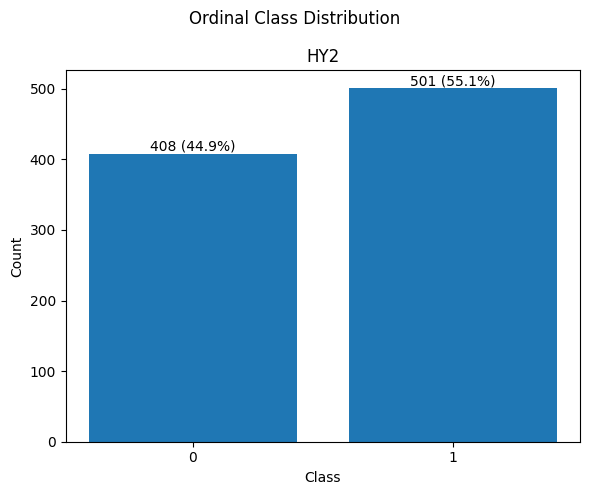

In [4]:
import pandas as pd
import json
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

current_dir = Path.cwd()
project_root = current_dir.parents[3]

y_HY2 = pd.read_csv(
    project_root / "SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY2.csv",
    index_col=0
)

print("y_HY2 shape:", y_HY2.shape)

# Crear una sola figura
fig, ax = plt.subplots(figsize=(6,5))

# Calcular conteos y porcentajes
counts = y_HY2.iloc[:, 0].value_counts().sort_index()
percentages = counts / counts.sum() * 100

# Crear barras
bars = ax.bar(counts.index.astype(str), counts.values)

# Añadir etiquetas (count + porcentaje)
for i, (count, pct) in enumerate(zip(counts.values, percentages.values)):
    ax.text(i, count, f"{count} ({pct:.1f}%)",
            ha='center', va='bottom')

# Labels
ax.set_title("HY2")
ax.set_xlabel("Class")
ax.set_ylabel("Count")

plt.suptitle("Ordinal Class Distribution")
plt.tight_layout()
plt.show()

# Files 

In [5]:
import os

with open(project_root/"SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/Domain_data.json", "r") as archivo:
    full_domain = json.load(archivo)

with open(project_root/"SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/UPDRS_Domain_data.json", "r") as archivo:
    updrs_domain = json.load(archivo)

X_multiples= { 'X_STATS':project_root/'SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_STATS.csv', 
                    'X_V06_STATS': project_root/'SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_V06+STATS.csv',
                      'X_V06_DELTA': project_root/'SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_V06+Deltas.csv'}

y_multiples = {'HY2': project_root/'SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY2.csv' }

outoutput_dir = project_root/'SCRIPTS/PYTHON/MODEL_ANALYSIS/Performance_Results/HY2'

dominios_updrs = {
    'X_STATS': {

        'examen_motor': updrs_domain['SC_data'] + updrs_domain['UPDRS_MOTOR_STATS'],
        'impacto_motor': updrs_domain['SC_data'] + updrs_domain['UPDRS_IMPACTO_MOTOR_STATS'],
        'non_motor': updrs_domain['SC_data'] + updrs_domain['UPDRS_NO_MOTOR_STATS']
    },

    'X_V06_STATS': {
        
        'examen_motor': updrs_domain['SC_data'] + updrs_domain['UPDRS_MOTOR_V06'] + updrs_domain['UPDRS_MOTOR_STATS'],
        'impacto_motor': updrs_domain['SC_data'] + updrs_domain['UPDRS_IMPACTO_MOTOR_V06'] + updrs_domain['UPDRS_IMPACTO_MOTOR_STATS'],
        'non_motor': updrs_domain['SC_data'] + updrs_domain['UPDRS_NO_MOTOR_V06'] + updrs_domain['UPDRS_NO_MOTOR_STATS']
    },

    'X_V06_DELTA': {
        'examen_motor': updrs_domain['SC_data'] + updrs_domain['UPDRS_MOTOR_V06'] + updrs_domain['UPDRS_MOTOR_delta'],
        'impacto_motor': updrs_domain['SC_data'] + updrs_domain['UPDRS_IMPACTO_MOTOR_V06'] + updrs_domain['UPDRS_IMPACTO_MOTOR_delta'],
        'non_motor': updrs_domain['SC_data'] + updrs_domain['UPDRS_NO_MOTOR_V06'] + updrs_domain['UPDRS_NO_MOTOR_delta']
    }
}

cols_updrs_full={}
for val in dominios_updrs:
    cols_updrs_val=[]
    for val_sub in dominios_updrs[val]:
        print(f"Evaluating domain: {val} - {val_sub}")
        cols_updrs_val+=dominios_updrs[val][val_sub]
    cols_updrs_full[val]=cols_updrs_val

cols_updrs_full['X_V06_STATS']=list(set(cols_updrs_full['X_V06_STATS']))
cols_updrs_full['X_STATS']=list(set(cols_updrs_full['X_STATS']))
cols_updrs_full['X_V06_DELTA']=list(set(cols_updrs_full['X_V06_DELTA']))


Evaluating domain: X_STATS - examen_motor
Evaluating domain: X_STATS - impacto_motor
Evaluating domain: X_STATS - non_motor
Evaluating domain: X_V06_STATS - examen_motor
Evaluating domain: X_V06_STATS - impacto_motor
Evaluating domain: X_V06_STATS - non_motor
Evaluating domain: X_V06_DELTA - examen_motor
Evaluating domain: X_V06_DELTA - impacto_motor
Evaluating domain: X_V06_DELTA - non_motor


# BINARY UPDRS FULL DOMAIN

## Performance Evaluation

In [6]:
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    roc_auc_score,
    precision_recall_fscore_support,
    confusion_matrix,
)


def _compute_metrics_binary(
    y_true,
    y_pred,
    y_proba=None,
    positive_label=1,
    cost_matrix=None
):
    metrics = {}

    y_true = np.asarray(y_true, dtype=int).ravel()
    y_pred = np.asarray(y_pred, dtype=int).ravel()

    # =========================
    # GLOBAL METRICS
    # =========================
    metrics["accuracy"] = accuracy_score(y_true, y_pred)
    metrics["f1"] = f1_score(y_true, y_pred, pos_label=positive_label, zero_division=0)
    metrics["recall"] = recall_score(y_true, y_pred, pos_label=positive_label, zero_division=0)
    metrics["precision"] = precision_score(y_true, y_pred, pos_label=positive_label, zero_division=0)

    # =========================
    # COST MATRIX
    # =========================
    # Formato:
    # cost_matrix[true_class, predicted_class]
    #
    # Por defecto:
    #   TN = 0
    #   FP = 1
    #   FN = 5
    #   TP = 0
    if cost_matrix is None:
        cost_matrix = np.array([
            [0, 1],
            [5, 0]
        ], dtype=float)
    else:
        cost_matrix = np.asarray(cost_matrix, dtype=float)

    sample_costs = cost_matrix[y_true, y_pred]

    metrics["misclassification_cost_mean"] = sample_costs.mean()
    metrics["misclassification_cost_total"] = sample_costs.sum()
    metrics["misclassification_score"] = -sample_costs.mean()

    for cls in [0, 1]:
        mask = (y_true == cls)
        if mask.sum() > 0:
            metrics[f"misclassification_cost_mean_true_class_{cls}"] = sample_costs[mask].mean()
        else:
            metrics[f"misclassification_cost_mean_true_class_{cls}"] = np.nan

    # =========================
    # AUC
    # =========================
    if y_proba is not None:
        try:
            y_proba = np.asarray(y_proba)

            if y_proba.ndim == 1:
                pos_scores = y_proba
            elif y_proba.ndim == 2 and y_proba.shape[1] >= 2:
                pos_scores = y_proba[:, 1]
            else:
                pos_scores = None

            metrics["auc"] = roc_auc_score(y_true, pos_scores) if pos_scores is not None else np.nan
        except Exception:
            metrics["auc"] = np.nan
    else:
        metrics["auc"] = np.nan

    # =========================
    # PER-CLASS METRICS
    # =========================
    prec, rec, f1, supp = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=[0, 1],
        zero_division=0
    )

    for i, cls in enumerate([0, 1]):
        metrics[f"precision_class_{cls}"] = prec[i]
        metrics[f"recall_class_{cls}"] = rec[i]
        metrics[f"f1_class_{cls}"] = f1[i]
        metrics[f"support_class_{cls}"] = supp[i]

    # =========================
    # CONFUSION-MATRIX METRICS
    # =========================
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    metrics["tn"] = tn
    metrics["fp"] = fp
    metrics["fn"] = fn
    metrics["tp"] = tp

    metrics["specificity"] = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    metrics["npv"] = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    metrics["fpr"] = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    metrics["fnr"] = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    return metrics


def _mean_metrics(metrics_list):
    keys = metrics_list[0].keys()
    return {k: np.mean([m[k] for m in metrics_list]) for k in keys}


def _build_row_binary(results, model_name):
    metric_names = list(results[0]["cv"].keys())

    row = {
        "model": model_name,
        "target_type": "binary",
        "classes": [0, 1],
        "n_classes": 2,
    }

    for metric in metric_names:
        cv_vals = [r["cv"][metric] for r in results]
        test_vals = [r["test"][metric] for r in results]

        row[f"{metric}_cv_mean"] = np.mean(cv_vals)
        row[f"{metric}_cv_std"] = np.std(cv_vals, ddof=1)

        row[f"{metric}_test_mean"] = np.mean(test_vals)
        row[f"{metric}_test_std"] = np.std(test_vals, ddof=1)

    return row


def evaluate_model_10x10_metrics_binary(
    model_dict: dict,
    X,
    y,
    n_outer=10,
    n_inner=10,
    test_size_outer=0.30,
    test_size_inner=0.30,
    random_state=42,
    positive_label=1,
    cost_matrix=None,
):
    # =========================
    # CONVERT TO NUMPY
    # =========================
    X_arr = X.values if hasattr(X, "iloc") else np.asarray(X)
    y_arr = y.values if hasattr(y, "iloc") else np.asarray(y)
    y_arr = np.asarray(y_arr).ravel().astype(int)

    unique_classes = np.unique(y_arr)
    if len(unique_classes) != 2:
        raise ValueError(
            f"El target y debe ser binario. Clases encontradas: {unique_classes}"
        )

    # Opcional: normalizar etiquetas a {0, 1}
    # Si ya vienen como 0 y 1, no cambia nada.
    if not np.array_equal(np.sort(unique_classes), np.array([0, 1])):
        mapping = {unique_classes[0]: 0, unique_classes[1]: 1}
        y_arr = np.vectorize(mapping.get)(y_arr)
        positive_label = 1

    all_rows = []

    # =========================
    # LOOP MODELS
    # =========================
    for model_name, model in model_dict.items():
        print(f"Evaluating model: {model_name}")

        outer_cv = StratifiedShuffleSplit(
            n_splits=n_outer,
            test_size=test_size_outer,
            random_state=random_state
        )

        results = []

        # =========================
        # OUTER LOOP
        # =========================
        for outer_fold, (train_idx, test_idx) in enumerate(
            outer_cv.split(X_arr, y_arr),
            start=1
        ):
            X_train_outer, X_test_outer = X_arr[train_idx], X_arr[test_idx]
            y_train_outer, y_test_outer = y_arr[train_idx], y_arr[test_idx]

            inner_cv = StratifiedShuffleSplit(
                n_splits=n_inner,
                test_size=test_size_inner,
                random_state=random_state + outer_fold
            )

            inner_scores = []

            # =========================
            # INNER LOOP
            # =========================
            for train_inner_idx, val_inner_idx in inner_cv.split(X_train_outer, y_train_outer):
                X_train_inner = X_train_outer[train_inner_idx]
                y_train_inner = y_train_outer[train_inner_idx]
                X_val_inner = X_train_outer[val_inner_idx]
                y_val_inner = y_train_outer[val_inner_idx]

                est = clone(model)
                est.fit(X_train_inner, y_train_inner)

                y_pred_val = est.predict(X_val_inner)

                y_proba_val = (
                    est.predict_proba(X_val_inner)
                    if hasattr(est, "predict_proba")
                    else None
                )

                inner_scores.append(
                    _compute_metrics_binary(
                        y_true=y_val_inner,
                        y_pred=y_pred_val,
                        y_proba=y_proba_val,
                        positive_label=positive_label,
                        cost_matrix=cost_matrix
                    )
                )

            cv_mean_scores = _mean_metrics(inner_scores)

            # =========================
            # FINAL MODEL (OUTER TEST)
            # =========================
            final_model = clone(model)
            final_model.fit(X_train_outer, y_train_outer)

            y_pred_test = final_model.predict(X_test_outer)

            y_proba_test = (
                final_model.predict_proba(X_test_outer)
                if hasattr(final_model, "predict_proba")
                else None
            )

            test_scores = _compute_metrics_binary(
                y_true=y_test_outer,
                y_pred=y_pred_test,
                y_proba=y_proba_test,
                positive_label=positive_label,
                cost_matrix=cost_matrix
            )

            results.append({
                "cv": cv_mean_scores,
                "test": test_scores
            })

        # =========================
        # SAVE RESULT ROW
        # =========================
        all_rows.append(
            _build_row_binary(
                results=results,
                model_name=model_name,
            )
        )

    return pd.DataFrame(all_rows)

## Models

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler

binary_classification_model = {

    "decision_tree": DecisionTreeClassifier(
        random_state=42,
        class_weight = 'balanced'
    ),

    "random_forest": RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight = 'balanced'
    ),

    "extra_trees": ExtraTreesClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight = 'balanced'
    ),

    "xgboost": XGBClassifier(
        tree_method="hist",
        eval_metric="logloss",
        n_jobs=-1,
        random_state=42
    ),

    "adaboost": AdaBoostClassifier(
        algorithm="SAMME", 
        random_state=42
    ),

    "svm": SVC(
        kernel="rbf",
        probability=True,  
        random_state=42,
        class_weight = 'balanced'
    ),

    "logistic_regression": LogisticRegression(
        random_state=42,
        n_jobs=-1,
        max_iter=10000,
        class_weight = 'balanced'
    ),

    "knn": KNeighborsClassifier(
        n_jobs=-1
    ),

    "gaussian_nb": GaussianNB()
}

# Diccionario con MinMaxScaler
models_minmax_binary = {
    "minmax_" + name: Pipeline([
        ("scaler", MinMaxScaler()),
        ("model", model)
    ])
    for name, model in binary_classification_model.items()
}

# Diccionario con StandardScaler
models_standard_binary = {
    "standard_" + name: Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])
    for name, model in binary_classification_model.items()
}

## SCALER SELECTION


In [9]:
# UPDRS DOAMIN
list_results_final = []
for val in dominios_updrs:
    print(f"Evaluating domain: {val}")
    path=X_multiples[val]
    X=pd.read_csv(path, index_col=0)
    print(f'X shape inicial: {X.shape}')
    X = X[cols_updrs_full[val]]
    print(f'X shape final UPDRS FULL DOMAIN: {X.shape}')
    path=y_multiples['HY2']
    y=pd.read_csv(path, index_col=0)
    list_results = []

    for scaler in ['NoScaler', 'MINMAX', 'STANDARD']:
        if scaler == 'NoScaler':
            model_dict_use = binary_classification_model
        if scaler == 'MINMAX':
            model_dict_use = models_minmax_binary
        if scaler == 'STANDARD':
            model_dict_use = models_standard_binary

        df=evaluate_model_10x10_metrics_binary(model_dict=model_dict_use, 
                                                X=X, 
                                                y=y)
        list_results.append(df)
        
    df_val=pd.concat(list_results, ignore_index=True)
    df_val['X_Processing']=val
    list_results_final.append(df_val)

df_final=pd.concat(list_results_final, ignore_index=True)
df_final.to_csv(f'{outoutput_dir}/Default_and_Scalers_Binary_HY2.csv')

Evaluating domain: X_STATS
X shape inicial: (909, 931)
X shape final UPDRS FULL DOMAIN: (909, 301)
Evaluating model: decision_tree
Evaluating model: random_forest
Evaluating model: extra_trees
Evaluating model: xgboost
Evaluating model: adaboost
Evaluating model: svm
Evaluating model: logistic_regression
Evaluating model: knn
Evaluating model: gaussian_nb
Evaluating model: minmax_decision_tree
Evaluating model: minmax_random_forest
Evaluating model: minmax_extra_trees
Evaluating model: minmax_xgboost
Evaluating model: minmax_adaboost
Evaluating model: minmax_svm
Evaluating model: minmax_logistic_regression
Evaluating model: minmax_knn
Evaluating model: minmax_gaussian_nb
Evaluating model: standard_decision_tree
Evaluating model: standard_random_forest
Evaluating model: standard_extra_trees
Evaluating model: standard_xgboost
Evaluating model: standard_adaboost
Evaluating model: standard_svm
Evaluating model: standard_logistic_regression
Evaluating model: standard_knn
Evaluating model: s

In [10]:
# FUNCION DE SELECCION DE MEJOR PIPELINE FASE 1
# CRITERIO FULL DOMAIN: AUC CV
# CRITERIO PARA SUBDOMAINS: AUC CV LA SELECCION DE MODELOS POR SUBDOMINIO Y AUC

models_names={'DT':['decision_tree','minmax_decision_tree','standard_decision_tree'], 
              'RF':['random_forest','minmax_random_forest','standard_random_forest'], 
              'ET':['extra_trees','minmax_extra_trees','standard_extra_trees'], 
              'XGB':['xgboost','minmax_xgboost','standard_xgboost'], 
              'ADA':['adaboost','minmax_adaboost','standard_adaboost'], 
              'SVM':['svm','minmax_svm','standard_svm'], 
              'LR':['logistic_regression','minmax_logistic_regression','standard_logistic_regression'], 
              'KNN':['knn','minmax_knn','standard_knn'], 
              'GNB':['gaussian_nb','minmax_gaussian_nb','standard_gaussian_nb']}

# ========================================================================
#    SELECCION DE MEJOR PIPELINE POR MODELO SEGUN AUC CV EN FULL DOMAIN
# ========================================================================

performance_df = pd.read_csv(f'{project_root}/SCRIPTS/PYTHON/MODEL_ANALYSIS/Performance_Results/HY2/Default_and_Scalers_Binary_HY2.csv', index_col=0)
# SELECCION DE MEJOR PIPELINE POR MODELO SEGUN AUC CV EN FULL DOMAIN
rows_selected = []
for model in models_names:
    df_model = performance_df[performance_df['model'].isin(models_names[model])]
    best_row = df_model.loc[df_model['auc_cv_mean'].idxmax()]
    print(f"Best pipeline for {model} in {best_row['X_Processing']}: {best_row['model']} with AUC CV mean: {best_row['auc_cv_mean']:.4f}")
    rows_selected.append([best_row['model'], best_row['X_Processing'], best_row['auc_cv_mean'], best_row['auc_cv_std']])

df_models_selected_full = pd.DataFrame(rows_selected, columns=["model", "X_Processing", "auc_cv_mean", "auc_cv_std"])
df_models_selected_full.to_csv(f'{outoutput_dir}/Best_Pipelines_Selected_Full_Domain_Binary_HY2_PHASE_1.csv')
df_models_selected_full

Best pipeline for DT in X_STATS: minmax_decision_tree with AUC CV mean: 0.8713
Best pipeline for RF in X_V06_STATS: minmax_random_forest with AUC CV mean: 0.9679
Best pipeline for ET in X_V06_STATS: extra_trees with AUC CV mean: 0.9683
Best pipeline for XGB in X_V06_STATS: xgboost with AUC CV mean: 0.9663
Best pipeline for ADA in X_STATS: adaboost with AUC CV mean: 0.9633
Best pipeline for SVM in X_V06_STATS: svm with AUC CV mean: 0.9696
Best pipeline for LR in X_V06_DELTA: minmax_logistic_regression with AUC CV mean: 0.9671
Best pipeline for KNN in X_STATS: minmax_knn with AUC CV mean: 0.9446
Best pipeline for GNB in X_STATS: standard_gaussian_nb with AUC CV mean: 0.9406


,model,X_Processing,auc_cv_mean,auc_cv_std
0,minmax_decision_tree,X_STATS,0.871277,0.009751
1,minmax_random_forest,X_V06_STATS,0.967887,0.004053
2,extra_trees,X_V06_STATS,0.968339,0.004120
3,xgboost,X_V06_STATS,0.966282,0.004754
4,adaboost,X_STATS,0.963299,0.006336
5,svm,X_V06_STATS,0.969564,0.005171
6,minmax_logistic_regression,X_V06_DELTA,0.967103,0.005528
7,minmax_knn,X_STATS,0.944571,0.004906
8,standard_gaussian_nb,X_STATS,0.940570,0.006428


In [11]:
X_full_domain = {
    'decision_tree': 'X_STATS',
    'random_forest': 'X_V06_STATS',
    'extra_trees': 'X_V06_STATS',
    'xgboost': 'X_V06_STATS',
    'adaboost': 'X_STATS',
    'svm': 'X_V06_STATS',
    'logistic_regression': 'X_V06_DELTA',
    'knn': 'X_STATS',
    'gaussian_nb': 'X_STATS'
}


pipelines_full_domain = {
    'decision_tree': Pipeline([
        ("scaler", MinMaxScaler()),
        ("model", binary_classification_model['decision_tree'])
    ]),

    'random_forest': Pipeline([
        ("scaler", MinMaxScaler()),
        ("model", binary_classification_model['random_forest'])
    ]),

    'extra_trees': Pipeline([
        ("model", binary_classification_model['extra_trees'])
    ]),

    'xgboost': Pipeline([
        ("model", binary_classification_model['xgboost'])
    ]),

    'adaboost': Pipeline([
        ("model", binary_classification_model['adaboost'])
    ]),

    'svm': Pipeline([
        ("model", binary_classification_model['svm'])
    ]),

    'logistic_regression': Pipeline([
        ("scaler", MinMaxScaler()),
        ("model", binary_classification_model['logistic_regression'])
    ]),

    'knn': Pipeline([
        ("scaler", MinMaxScaler()),
        ("model", binary_classification_model['knn'])
    ]),

    'gaussian_nb': Pipeline([
        ("scaler", StandardScaler()),
        ("model", binary_classification_model['gaussian_nb'])
    ])
}


##  Feature Selection

In [14]:
# feature selection
from sklearn.feature_selection import SelectKBest, mutual_info_classif, RFECV
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import SelectPercentile
from sklearn.feature_selection import VarianceThreshold



pipelines_full_domain_MI = {
    f"{name}_MI": Pipeline([
        ("scaler", MinMaxScaler() if name in ["knn", "logistic_regression",'decision_tree','random_forest'] else StandardScaler() if name in ['gaussian_nb'] else "passthrough"),
        ("selector0", VarianceThreshold(threshold=0.0)),
        ("selector1", SelectPercentile(mutual_info_classif, percentile=80)),
        ("model", clone(model))
    ])
    for name, model in binary_classification_model.items()
}

from scipy.stats import spearmanr
def spearman_selector(X, y):
    scores = []
    pvalues = []
    
    for i in range(X.shape[1]):
        corr, p = spearmanr(X[:, i], y)
        
        if np.isnan(corr):
            corr = 0.0
        if np.isnan(p):
            p = 1.0
        
        scores.append(abs(corr))
        pvalues.append(p)
    
    return np.array(scores), np.array(pvalues)

pipelines_full_domain_SP = {
    f"{name}_SP": Pipeline([
        ("scaler", MinMaxScaler() if name in ["knn", "logistic_regression",'decision_tree','random_forest'] else StandardScaler() if name in ['gaussian_nb'] else "passthrough"),
        ("selector0", VarianceThreshold(threshold=0.0)),
        ("selector1", SelectKBest(score_func=spearman_selector, k=200)),
        ("model", clone(model))
    ])
    for name, model in binary_classification_model.items()
}

pipelines_full_domain_SP_RFECV = {
    f"{name}_SP_RFECV": Pipeline([
        ("scaler", MinMaxScaler() if name in ["knn", "logistic_regression",'decision_tree','random_forest'] else StandardScaler() if name in ['gaussian_nb'] else "passthrough"),
        ("selector0", VarianceThreshold(threshold=0.0)),
        ("selector1", SelectKBest(score_func=spearman_selector, k=200)),
        ("selector2", RFECV(
            estimator=clone(model),
            step=15,
            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
            scoring="roc_auc",
            n_jobs=-1
        )),
        ("model", clone(model))
    ])
    for name, model in binary_classification_model.items()
}

pipelines_full_domain_MI_RFECV = {
    f"{name}_MI_RFECV": Pipeline([
        ("scaler", MinMaxScaler() if name in ["knn", "logistic_regression",'decision_tree','random_forest'] else StandardScaler() if name in ['gaussian_nb'] else "passthrough"),
        ("selector0", VarianceThreshold(threshold=0.0)),
        ("selector1", SelectPercentile(mutual_info_classif, percentile=50)),
        ("selector2", RFECV(
            estimator=clone(model),
            step=15,
            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
            scoring="roc_auc",
            n_jobs=-1
        )),
        ("model", clone(model))
    ])
    for name, model in binary_classification_model.items()
}

In [15]:
list_results = []
for model in X_full_domain:
    if X_full_domain[model] == 'X_STATS':
        X_path = X_multiples['X_STATS']
        X_cols = cols_updrs_full['X_STATS']

    elif X_full_domain[model] == 'X_V06_STATS':
        X_path = X_multiples['X_V06_STATS']
        X_cols = cols_updrs_full['X_V06_STATS']
    elif X_full_domain[model] == 'X_V06_DELTA':
        X_path = X_multiples['X_V06_DELTA']
        X_cols = cols_updrs_full['X_V06_DELTA']
    

    X = pd.read_csv(X_path, index_col=0)[X_cols]
    print(f'X shape used for model {model} in {X_full_domain[model]}: {X.shape}')
    y = pd.read_csv(y_multiples['HY2'], index_col=0)
    print(f"Evaluating model: {model} with pipeline: {X_full_domain[model]} in full domain")
    
    if model in ["decision_tree", "random_forest", "extra_trees", "xgboost", "logistic_regression",'adaboost']:
        print('Feature selection: SP_RFECV')
        df1 = evaluate_model_10x10_metrics_binary(
            model_dict={f"{model}_SP_RFECV": pipelines_full_domain_SP_RFECV[f"{model}_SP_RFECV"]},
            X=X,
            y=y
        )
        print(f'AUC CV mean for {model}_SP_RFECV: {df1["auc_cv_mean"].values[0]:.4f}')
        list_results.append(df1)
        
        print('Feature selection: MI_RFECV')
        df4=evaluate_model_10x10_metrics_binary(
            model_dict={f"{model}_MI_RFECV": pipelines_full_domain_MI_RFECV[f"{model}_MI_RFECV"]},
            X=X,
            y=y
        )
        print(f'AUC CV mean for {model}_MI_RFECV: {df4["auc_cv_mean"].values[0]:.4f}')
        list_results.append(df4)
    
    print('Feature selection: MI')
    df2=evaluate_model_10x10_metrics_binary(
        model_dict={f"{model}_MI": pipelines_full_domain_MI[f"{model}_MI"]},
        X=X,
        y=y
    )
    print(f'AUC CV mean for {model}_MI: {df2["auc_cv_mean"].values[0]:.4f}')
    list_results.append(df2)
    print('Feature selection: SP')

    df3=evaluate_model_10x10_metrics_binary(
        model_dict={f"{model}_SP": pipelines_full_domain_SP[f"{model}_SP"]},
        X=X,
        y=y
    )
    print(f'AUC CV mean for {model}_SP: {df3["auc_cv_mean"].values[0]:.4f}')
    list_results.append(df3)

    

df_full_Feature_Selection = pd.concat(list_results, ignore_index=True)
print(f'Feature Selection Results saved to: {project_root}/SCRIPTS/PYTHON/MODEL_ANALYSIS/Performance_Results/HY2/UPDRS/Feature_Selection_LATE_HY2.csv')
df_full_Feature_Selection.to_csv(f'{outoutput_dir}/Feature_Selection_LATE_HY2.csv', index=False)
df_full_Feature_Selection

X shape used for model decision_tree in X_STATS: (909, 301)
Evaluating model: decision_tree with pipeline: X_STATS in full domain
Feature selection: SP_RFECV
Evaluating model: decision_tree_SP_RFECV
AUC CV mean for decision_tree_SP_RFECV: 0.9321
Feature selection: MI_RFECV
Evaluating model: decision_tree_MI_RFECV
AUC CV mean for decision_tree_MI_RFECV: 0.9329
Feature selection: MI
Evaluating model: decision_tree_MI
AUC CV mean for decision_tree_MI: 0.8682
Feature selection: SP
Evaluating model: decision_tree_SP
AUC CV mean for decision_tree_SP: 0.8700
X shape used for model random_forest in X_V06_STATS: (909, 360)
Evaluating model: random_forest with pipeline: X_V06_STATS in full domain
Feature selection: SP_RFECV
Evaluating model: random_forest_SP_RFECV
AUC CV mean for random_forest_SP_RFECV: 0.9671
Feature selection: MI_RFECV
Evaluating model: random_forest_MI_RFECV
AUC CV mean for random_forest_MI_RFECV: 0.9667
Feature selection: MI
Evaluating model: random_forest_MI
AUC CV mean for

,model,target_type,classes,n_classes,accuracy_cv_mean,accuracy_cv_std,accuracy_test_mean,accuracy_test_std,f1_cv_mean,f1_cv_std,...,npv_test_mean,npv_test_std,fpr_cv_mean,fpr_cv_std,fpr_test_mean,fpr_test_std,fnr_cv_mean,fnr_cv_std,fnr_test_mean,fnr_test_std
0,decision_tree_SP_RFECV,binary,"[0, 1]",2,0.879791,0.006872,0.890476,0.011250,0.885099,0.006489,...,0.835443,0.026552,0.077209,0.027425,0.055285,0.031789,0.155429,0.020420,0.154000,0.030864
1,decision_tree_MI_RFECV,binary,"[0, 1]",2,0.879529,0.006638,0.890476,0.011250,0.884818,0.006114,...,0.835443,0.026552,0.077326,0.027551,0.055285,0.031789,0.155810,0.019750,0.154000,0.030864
2,decision_tree_MI,binary,"[0, 1]",2,0.870000,0.009278,0.891209,0.018761,0.882265,0.007987,...,0.894085,0.024725,0.149535,0.018313,0.139024,0.030287,0.114000,0.008436,0.084000,0.020894
3,decision_tree_SP,binary,"[0, 1]",2,0.871990,0.007692,0.892674,0.015546,0.884392,0.006366,...,0.890902,0.028080,0.150000,0.016490,0.130894,0.020798,0.110000,0.005221,0.088000,0.024905
4,random_forest_SP_RFECV,binary,"[0, 1]",2,0.917749,0.007814,0.930403,0.014134,0.923191,0.007714,...,0.904357,0.023943,0.061395,0.008034,0.053659,0.018058,0.099333,0.013787,0.082667,0.023768
5,random_forest_MI_RFECV,binary,"[0, 1]",2,0.920262,0.008348,0.932234,0.018049,0.925378,0.008162,...,0.907801,0.024666,0.055581,0.007532,0.053659,0.027154,0.099524,0.013486,0.079333,0.024231
6,random_forest_MI,binary,"[0, 1]",2,0.921466,0.007292,0.933700,0.015774,0.926581,0.007147,...,0.908231,0.024274,0.055349,0.007235,0.050407,0.025073,0.097524,0.012644,0.079333,0.025033
7,random_forest_SP,binary,"[0, 1]",2,0.919948,0.008675,0.932234,0.013403,0.925193,0.008300,...,0.908044,0.023043,0.057558,0.010229,0.053659,0.028731,0.098476,0.012484,0.079333,0.024027
8,extra_trees_SP_RFECV,binary,"[0, 1]",2,0.915550,0.008134,0.929304,0.016477,0.921542,0.007762,...,0.907365,0.024316,0.068953,0.011005,0.060163,0.030708,0.097143,0.012442,0.079333,0.024027
9,extra_trees_MI_RFECV,binary,"[0, 1]",2,0.918168,0.009075,0.926740,0.016919,0.923862,0.008630,...,0.906928,0.027157,0.064767,0.009928,0.065854,0.022495,0.095810,0.012636,0.079333,0.026750


In [16]:
df_full_Feature_Selection=pd.read_csv(f'{outoutput_dir}/Feature_Selection_LATE_HY2.csv')
df_models_selected_full=pd.read_csv(f'{outoutput_dir}/Best_Pipelines_Selected_Full_Domain_Binary_HY2_PHASE_1.csv')

models_names={'DT':['decision_tree','minmax_decision_tree','standard_decision_tree','decision_tree_SP_RFECV','decision_tree_MI_RFECV','decision_tree_MI','decision_tree_SP'], 
              'RF':['random_forest','minmax_random_forest','standard_random_forest', 'random_forest_SP_RFECV','random_forest_MI_RFECV','random_forest_MI','random_forest_SP'], 
              'ET':['extra_trees','minmax_extra_trees','standard_extra_trees', 'extra_trees_SP_RFECV','extra_trees_MI_RFECV','extra_trees_MI','extra_trees_SP'], 
              'XGB':['xgboost','minmax_xgboost','standard_xgboost', 'xgboost_SP_RFECV','xgboost_MI_RFECV','xgboost_MI','xgboost_SP'], 
              'ADA':['adaboost','minmax_adaboost','standard_adaboost', 'adaboost_SP_RFECV','adaboost_MI_RFECV','adaboost_MI','adaboost_SP'], 
              'SVM':['svm','minmax_svm','standard_svm', 'svm_SP_RFECV','svm_MI_RFECV','svm_MI','svm_SP'], 
              'LR':['logistic_regression','minmax_logistic_regression','standard_logistic_regression', 'logistic_regression_SP_RFECV','logistic_regression_MI_RFECV','logistic_regression_MI','logistic_regression_SP'], 
              'KNN':['knn','minmax_knn','standard_knn', 'knn_SP_RFECV','knn_MI_RFECV','knn_MI','knn_SP'], 
              'GNB':['gaussian_nb','minmax_gaussian_nb','standard_gaussian_nb', 'gaussian_nb_SP_RFECV','gaussian_nb_MI_RFECV','gaussian_nb_MI','gaussian_nb_SP']}


df_select=pd.concat([df_full_Feature_Selection, df_models_selected_full], ignore_index=True)

rows_selected = []
for model in models_names:
    df_model = df_select[df_select['model'].isin(models_names[model])]
    print(df_model[['model', 'auc_cv_mean', 'auc_cv_std']].sort_values(by='auc_cv_mean', ascending=False))
    best_row = df_model.loc[df_model['auc_cv_mean'].idxmax()]
    print(f"Best pipeline for {model}: {best_row['model']} with AUC CV mean: {best_row['auc_cv_mean']:.4f}")
    rows_selected.append([best_row['model'], best_row['auc_cv_mean'], best_row['auc_cv_std']])

df_models_selected_full_phase2 = pd.DataFrame(rows_selected, columns=["model", "auc_cv_mean", "auc_cv_std"])
df_models_selected_full_phase2.to_csv(f'{outoutput_dir}/Best_Pipelines_Selected_Full_Domain_Binary_HY2_PHASE_2.csv', index=False)
df_models_selected_full_phase2

                     model  auc_cv_mean  auc_cv_std
1   decision_tree_MI_RFECV     0.932854    0.006147
0   decision_tree_SP_RFECV     0.932068    0.006237
30    minmax_decision_tree     0.871277    0.009751
3         decision_tree_SP     0.870000    0.008399
2         decision_tree_MI     0.868233    0.009908
Best pipeline for DT: decision_tree_MI_RFECV with AUC CV mean: 0.9329
                     model  auc_cv_mean  auc_cv_std
6         random_forest_MI     0.968710    0.004675
31    minmax_random_forest     0.967887    0.004053
7         random_forest_SP     0.967434    0.004456
4   random_forest_SP_RFECV     0.967113    0.004060
5   random_forest_MI_RFECV     0.966662    0.004293
Best pipeline for RF: random_forest_MI with AUC CV mean: 0.9687
                   model  auc_cv_mean  auc_cv_std
32           extra_trees     0.968339    0.004120
10        extra_trees_MI     0.968271    0.004146
11        extra_trees_SP     0.967127    0.004459
8   extra_trees_SP_RFECV     0.965685    0

,model,auc_cv_mean,auc_cv_std
0,decision_tree_MI_RFECV,0.932854,0.006147
1,random_forest_MI,0.968710,0.004675
2,extra_trees,0.968339,0.004120
3,xgboost_MI,0.966375,0.004526
4,adaboost_SP,0.963841,0.005127
5,svm_SP,0.969780,0.004757
6,logistic_regression_MI,0.968822,0.005345
7,knn_SP,0.946402,0.005741
8,gaussian_nb_MI,0.941410,0.005661


## Bayesian Optimization

In [17]:
from skopt.space import Real, Integer, Categorical



pipelines_full_domain_opt = {
    'decision_tree': Pipeline([
        ("scaler", MinMaxScaler()),
        ("model", binary_classification_model['decision_tree'])
    ]),

    'random_forest': Pipeline([
        ("scaler", MinMaxScaler()),
        ("selector0", VarianceThreshold(threshold=0.0)),
        ("selector1", SelectPercentile(mutual_info_classif, percentile=80)),
        ("model", binary_classification_model['random_forest'])
    ]),

    'extra_trees': Pipeline([
        ("model", binary_classification_model['extra_trees'])
    ]),

    'xgboost': Pipeline([
        ("model", binary_classification_model['xgboost'])
    ]),

    'adaboost': Pipeline([
        ("selector0", VarianceThreshold(threshold=0.0)),
        ("selector1", SelectKBest(score_func=spearman_selector, k=200)),
        ("model", binary_classification_model['adaboost'])
    ]),

    'svm': Pipeline([
        ("selector0", VarianceThreshold(threshold=0.0)),
        ("selector1", SelectKBest(score_func=spearman_selector, k=200)),
        ("model", binary_classification_model['svm'])
    ]),

    'logistic_regression': Pipeline([
        ("scaler", MinMaxScaler()),
        ("selector0", VarianceThreshold(threshold=0.0)),
        ("selector1", SelectPercentile(mutual_info_classif, percentile=80)),
        ("model", binary_classification_model['logistic_regression'])
    ]),

    'knn': Pipeline([
        ("scaler", MinMaxScaler()),
        ("selector0", VarianceThreshold(threshold=0.0)),
        ("selector1", SelectKBest(score_func=spearman_selector, k=200)),
        ("model", binary_classification_model['knn'])
    ]),

    'gaussian_nb': Pipeline([
        ("scaler", StandardScaler()),
        ("selector0", VarianceThreshold(threshold=0.0)),
        ("selector1", SelectPercentile(mutual_info_classif, percentile=80)),
        ("model", binary_classification_model['gaussian_nb'])
    ])
}


search_spaces = {
    "decision_tree": {
        "model__criterion": Categorical(["gini", "entropy", "log_loss"]),
        "model__max_depth": Integer(2, 30),
        "model__min_samples_split": Integer(2, 30),
        "model__min_samples_leaf": Integer(1, 15),
        "model__max_features": Categorical([None, "sqrt", "log2"]),
    },

    "random_forest": {
        "model__n_estimators": Integer(100, 600),
        "model__criterion": Categorical(["gini", "entropy", "log_loss"]),
        "model__max_depth": Integer(3, 30),
        "model__min_samples_split": Integer(2, 30),
        "model__min_samples_leaf": Integer(1, 15),
        "model__max_features": Categorical([None, "sqrt", "log2"]),
        "model__bootstrap": Categorical([True, False]),
    },

    "extra_trees": {
        "model__n_estimators": Integer(100, 600),
        "model__criterion": Categorical(["gini", "entropy", "log_loss"]),
        "model__max_depth": Integer(3, 30),
        "model__min_samples_split": Integer(2, 30),
        "model__min_samples_leaf": Integer(1, 15),
        "model__max_features": Categorical([None, "sqrt", "log2"]),
        "model__bootstrap": Categorical([True, False]),
    },

    "xgboost": {
        "model__n_estimators": Integer(100, 600),
        "model__max_depth": Integer(3, 12),
        "model__learning_rate": Real(1e-3, 3e-1, prior="log-uniform"),
        "model__subsample": Real(0.5, 1.0),
        "model__colsample_bytree": Real(0.5, 1.0),
        "model__min_child_weight": Integer(1, 12),
        "model__gamma": Real(1e-8, 10.0, prior="log-uniform"),
        "model__reg_alpha": Real(1e-8, 10.0, prior="log-uniform"),
        "model__reg_lambda": Real(1e-6, 20.0, prior="log-uniform"),
    },

    "adaboost": {
        "model__n_estimators": Integer(30, 400),
        "model__learning_rate": Real(1e-3, 2.0, prior="log-uniform"),
    },

    "svm": {
        "model__C": Real(1e-3, 1e3, prior="log-uniform"),
        "model__gamma": Real(1e-5, 1e1, prior="log-uniform"),
    },

    "logistic_regression": {
        "model__C": Real(1e-4, 1e2, prior="log-uniform"),
        "model__solver": Categorical(["lbfgs", "newton-cg", "saga"]),
    },

    "knn": {
        "model__n_neighbors": Integer(1, 51),
        "model__weights": Categorical(["uniform", "distance"]),
        "model__p": Integer(1, 2),
    },

    "gaussian_nb": {
        "model__var_smoothing": Real(1e-12, 1e-6, prior="log-uniform"),
    },
}

In [18]:
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    roc_auc_score,
    precision_recall_fscore_support,
    confusion_matrix,
)

from skopt import BayesSearchCV


def _compute_metrics_binary(
    y_true,
    y_pred,
    y_proba=None,
    positive_label=1,
    cost_matrix=None
):
    metrics = {}

    y_true = np.asarray(y_true, dtype=int).ravel()
    y_pred = np.asarray(y_pred, dtype=int).ravel()

    metrics["accuracy"] = accuracy_score(y_true, y_pred)
    metrics["f1"] = f1_score(y_true, y_pred, pos_label=positive_label, zero_division=0)
    metrics["recall"] = recall_score(y_true, y_pred, pos_label=positive_label, zero_division=0)
    metrics["precision"] = precision_score(y_true, y_pred, pos_label=positive_label, zero_division=0)
 

    if cost_matrix is None:
        cost_matrix = np.array([
            [0, 1],
            [5, 0]
        ], dtype=float)
    else:
        cost_matrix = np.asarray(cost_matrix, dtype=float)

    sample_costs = cost_matrix[y_true, y_pred]
    metrics["misclassification_cost_mean"] = sample_costs.mean()
    metrics["misclassification_cost_total"] = sample_costs.sum()
    metrics["misclassification_score"] = -sample_costs.mean()

    for cls in [0, 1]:
        mask = (y_true == cls)
        metrics[f"misclassification_cost_mean_true_class_{cls}"] = (
            sample_costs[mask].mean() if mask.sum() > 0 else np.nan
        )

    if y_proba is not None:
        try:
            y_proba = np.asarray(y_proba)
            if y_proba.ndim == 1:
                pos_scores = y_proba
            elif y_proba.ndim == 2 and y_proba.shape[1] >= 2:
                pos_scores = y_proba[:, 1]
            else:
                pos_scores = None

            metrics["auc"] = roc_auc_score(y_true, pos_scores) if pos_scores is not None else np.nan
        except Exception:
            metrics["auc"] = np.nan
    else:
        metrics["auc"] = np.nan

    prec, rec, f1, supp = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=[0, 1],
        zero_division=0
    )

    for i, cls in enumerate([0, 1]):
        metrics[f"precision_class_{cls}"] = prec[i]
        metrics[f"recall_class_{cls}"] = rec[i]
        metrics[f"f1_class_{cls}"] = f1[i]
        metrics[f"support_class_{cls}"] = supp[i]

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    metrics["tn"] = tn
    metrics["fp"] = fp
    metrics["fn"] = fn
    metrics["tp"] = tp
    metrics["specificity"] = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    metrics["npv"] = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    metrics["fpr"] = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    metrics["fnr"] = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    return metrics


def _build_row_binary(results, model_name):
    cv_metric_names = list(results[0]["cv"].keys())
    test_metric_names = list(results[0]["test"].keys())

    row = {
        "model": model_name,
        "target_type": "binary",
        "classes": [0, 1],
        "n_classes": 2,
    }

    # metrics present in cv
    for metric in cv_metric_names:
        cv_vals = [r["cv"][metric] for r in results]
        row[f"{metric}_cv_mean"] = np.mean(cv_vals)
        row[f"{metric}_cv_std"] = np.std(cv_vals, ddof=1)

    # metrics present in test
    for metric in test_metric_names:
        test_vals = [r["test"][metric] for r in results]
        row[f"{metric}_test_mean"] = np.mean(test_vals)
        row[f"{metric}_test_std"] = np.std(test_vals, ddof=1)

    return row


def evaluate_model_10x10_metrics_binary_bayes(
    model_dict: dict,
    search_spaces: dict,   # <- nuevo: espacio por modelo
    X,
    y,
    n_outer=10,
    n_inner=10,
    n_iter=25,             # <- iteraciones bayesianas
    test_size_outer=0.30,
    test_size_inner=0.30,
    random_state=42,
    positive_label=1,
    cost_matrix=None,
    scoring="roc_auc",          # <- métrica de optimización del search
    n_jobs=-1,
):
    X_arr = X.values if hasattr(X, "iloc") else np.asarray(X)
    y_arr = y.values if hasattr(y, "iloc") else np.asarray(y)
    y_arr = np.asarray(y_arr).ravel().astype(int)

    unique_classes = np.unique(y_arr)
    if len(unique_classes) != 2:
        raise ValueError(f"El target y debe ser binario. Clases encontradas: {unique_classes}")

    if not np.array_equal(np.sort(unique_classes), np.array([0, 1])):
        mapping = {unique_classes[0]: 0, unique_classes[1]: 1}
        y_arr = np.vectorize(mapping.get)(y_arr)
        positive_label = 1

    all_rows = []

    for model_name, model in model_dict.items():
        print(f"Evaluating model with BayesSearchCV: {model_name}")

        if model_name not in search_spaces:
            raise ValueError(f"Falta search space para el modelo '{model_name}'")

        outer_cv = StratifiedShuffleSplit(
            n_splits=n_outer,
            test_size=test_size_outer,
            random_state=random_state
        )

        results = []

        for outer_fold, (train_idx, test_idx) in enumerate(
            outer_cv.split(X_arr, y_arr),
            start=1
        ):
            X_train_outer, X_test_outer = X_arr[train_idx], X_arr[test_idx]
            y_train_outer, y_test_outer = y_arr[train_idx], y_arr[test_idx]

            inner_cv = StratifiedShuffleSplit(
                n_splits=n_inner,
                test_size=test_size_inner,
                random_state=random_state + outer_fold
            )

            # Bayesian optimization dentro del loop interno
            opt = BayesSearchCV(
                estimator=clone(model),
                search_spaces=search_spaces[model_name],
                n_iter=n_iter,
                scoring=scoring,
                cv=inner_cv,
                n_jobs=n_jobs,
                refit=True,
                random_state=random_state + outer_fold,
                return_train_score=False,
                verbose=0
            )

            opt.fit(X_train_outer, y_train_outer)

            # score CV del mejor set de hiperparámetros
            best_cv_score = opt.best_score_

            # modelo final con mejores hiperparámetros sobre todo el outer-train
            final_model = opt.best_estimator_

            y_pred_test = final_model.predict(X_test_outer)
            y_proba_test = (
                final_model.predict_proba(X_test_outer)
                if hasattr(final_model, "predict_proba")
                else None
            )

            test_scores = _compute_metrics_binary(
                y_true=y_test_outer,
                y_pred=y_pred_test,
                y_proba=y_proba_test,
                positive_label=positive_label,
                cost_matrix=cost_matrix
            )

            # guardamos también el score de optimización interna
            cv_summary = {"bayes_best_cv_score": best_cv_score}

            # opcional: métricas del outer-train usando el best_estimator_
            y_pred_train_outer = final_model.predict(X_train_outer)
            y_proba_train_outer = (
                final_model.predict_proba(X_train_outer)
                if hasattr(final_model, "predict_proba")
                else None
            )

            train_outer_scores = _compute_metrics_binary(
                y_true=y_train_outer,
                y_pred=y_pred_train_outer,
                y_proba=y_proba_train_outer,
                positive_label=positive_label,
                cost_matrix=cost_matrix
            )

            # mezclamos ambas cosas en "cv"
            cv_summary.update(train_outer_scores)

            results.append({
                "cv": cv_summary,
                "test": test_scores,
                "best_params": opt.best_params_
            })

        all_rows.append(
            _build_row_binary(
                results=results,
                model_name=model_name,
            )
        )

    return pd.DataFrame(all_rows), results

In [ ]:
list_results = []
list_params = {}
for model in X_full_domain:
    if X_full_domain[model] == 'X_STATS':
        X_path = X_multiples['X_STATS']
        X_cols = cols_updrs_full['X_STATS']
    elif X_full_domain[model] == 'X_V06_STATS':
        X_path = X_multiples['X_V06_STATS']
        X_cols = cols_updrs_full['X_V06_STATS']
    elif X_full_domain[model] == 'X_V06_DELTA':
        X_path = X_multiples['X_V06_DELTA']
        X_cols = cols_updrs_full['X_V06_DELTA']

    X = pd.read_csv(X_path, index_col=0)[X_cols]
    y = pd.read_csv(y_multiples['HY2'], index_col=0).squeeze()
    print(f"Evaluating model: {model} with pipeline: {X_full_domain[model]} in full domain")
    df_metrics, results = evaluate_model_10x10_metrics_binary_bayes(
        model_dict={model: pipelines_full_domain_opt[model]},
        search_spaces=search_spaces,
        X=X,
        y=y,
        n_outer=10,
        n_inner=5,
    )

    print(f'AUC CV mean for {model}_OPT: {df_metrics["auc_cv_mean"].values[0]:.4f},{df_metrics["auc_test_mean"].values[0]:.4f}')
    list_results.append(df_metrics)
    list_params[f"{model}_OPT"] = results

df_full_Bayes_Optimization = pd.concat(list_results, ignore_index=True)
df_full_Bayes_Optimization.to_csv(f'{outoutput_dir}/BAYES_OPT_HY2.csv', index=False)
df_full_Bayes_Optimization




Evaluating model: decision_tree with pipeline: X_STATS in full domain
Evaluating model with BayesSearchCV: decision_tree
AUC CV mean for decision_tree_OPT: 0.9778,0.9602
Evaluating model: random_forest with pipeline: X_V06_STATS in full domain
Evaluating model with BayesSearchCV: random_forest


/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/numpy/ma/core.py:2885: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


In [ ]:
import json
from sklearn.base import clone

result = []

for key in list_params:
    for fold, val in enumerate(list_params[key]):
        result.append({
            "key": key,
            "fold": fold,
            "parameters": val["best_params"]
        })

# Guardar en archivo JSON
with open(f"{project_root}/SCRIPTS/PYTHON/MODEL_ANALYSIS/Performance_Results/HY2/best_params.json", "w") as f:
    json.dump(result, f, indent=4)


# Cargar JSON
with open(f"{project_root}/SCRIPTS/PYTHON/MODEL_ANALYSIS/Performance_Results/HY2/best_params.json", "r") as f:
    data = json.load(f)

pipelines_opt_fold = {}

for item in data:
    # Nombre base del modelo (sin _OPT)
    model_name = item["key"].replace("_OPT", "")
    
    # fold (empieza en 0 → lo pasamos a 1)
    fold = item["fold"] + 1
    
    # nombre final del pipeline
    new_name = f"{model_name}_opt_fold{fold}"
    
    # clonar pipeline base
    base_pipeline = pipelines_full_domain_opt[model_name]
    new_pipeline = clone(base_pipeline)
    
    # setear hiperparámetros
    new_pipeline.set_params(**item["parameters"])
    
    # guardar
    pipelines_opt_fold[new_name] = new_pipeline

In [ ]:
list_results = []
for model in pipelines_opt_fold:
    model_name = model.split("_opt_fold")[0]
    model_fold = model.split("_opt_fold")[1]
    fold = model.split("_opt_fold")[1]
    if X_full_domain[model_name] == 'X_STATS':
        X_path = X_multiples['X_STATS']
        X_cols = cols_updrs_full['X_STATS']
    elif X_full_domain[model_name] == 'X_V06_STATS':
        X_path = X_multiples['X_V06_STATS']
        X_cols = cols_updrs_full['X_V06_STATS']
    elif X_full_domain[model_name] == 'X_V06_DELTA':
        X_path = X_multiples['X_V06_DELTA']
        X_cols = cols_updrs_full['X_V06_DELTA']

    X = pd.read_csv(X_path, index_col=0)[X_cols]
    y = pd.read_csv(y_multiples['HY2'], index_col=0).squeeze()
    print(f'Evaluating model: {model_name} with pipeline {model_fold}')
    df_metrics = evaluate_model_10x10_metrics_binary(
        model_dict={model: pipelines_opt_fold[model]},
        X=X,
        y=y,
        n_outer=10,  # solo 1 fold externo
        n_inner=5, 
    )
    print(f'AUC CV mean for {model}: {df_metrics["auc_cv_mean"].values[0]:.4f},{df_metrics["auc_test_mean"].values[0]:.4f}')
    list_results.append(df_metrics)
df_full_Bayes_Optimization_Folds = pd.concat(list_results, ignore_index=True)
df_full_Bayes_Optimization_Folds.sort_values(by="auc_cv_mean", ascending=False, inplace=True)
df_full_Bayes_Optimization_Folds['model_type']=df_full_Bayes_Optimization_Folds.apply(lambda x: x['model'].split('_opt_fold')[0], axis=1)
df_full_Bayes_Optimization_Folds.to_csv(f'{outoutput_dir}/BAYES_OPT_FOLDS_HY2.csv', index=False)
df_full_Bayes_Optimization_Folds

Evaluating model: decision_tree with pipeline 1
Evaluating model: decision_tree_opt_fold1
AUC CV mean for decision_tree_opt_fold1: 0.9403,0.9579
Evaluating model: decision_tree with pipeline 2
Evaluating model: decision_tree_opt_fold2
AUC CV mean for decision_tree_opt_fold2: 0.9357,0.9496
Evaluating model: decision_tree with pipeline 3
Evaluating model: decision_tree_opt_fold3
AUC CV mean for decision_tree_opt_fold3: 0.9413,0.9571
Evaluating model: decision_tree with pipeline 4
Evaluating model: decision_tree_opt_fold4
AUC CV mean for decision_tree_opt_fold4: 0.9374,0.9535
Evaluating model: decision_tree with pipeline 5
Evaluating model: decision_tree_opt_fold5
AUC CV mean for decision_tree_opt_fold5: 0.9360,0.9509
Evaluating model: decision_tree with pipeline 6
Evaluating model: decision_tree_opt_fold6
AUC CV mean for decision_tree_opt_fold6: 0.9285,0.9406
Evaluating model: decision_tree with pipeline 7
Evaluating model: decision_tree_opt_fold7
AUC CV mean for decision_tree_opt_fold7:

In [ ]:

df_full_Bayes_Optimization_Folds=pd.read_csv(f'{outoutput_dir}/BAYES_OPT_FOLDS_HY2.csv')
# pipelines_opt_fold es un diccionario pre definido que contiene los pipelines con los mejores hiperparámetros por fold
dicts_models={}
list_models_selected=[]
for model_type in df_full_Bayes_Optimization_Folds['model_type'].unique():
    df_subset = df_full_Bayes_Optimization_Folds[df_full_Bayes_Optimization_Folds['model_type'] == model_type]
    best_row = df_subset.loc[df_subset['auc_cv_mean'].idxmax()]
    list_models_selected.append(best_row)
    dicts_models[best_row['model']] = pipelines_opt_fold[best_row['model']]
    print(f"Best fold for {model_type}: {best_row['model']} with AUC CV mean: {best_row['auc_cv_mean']:.4f}")

df_models_selected_full_phase3 = pd.DataFrame(list_models_selected)
df_models_selected_full_phase3.to_csv(f'{outoutput_dir}/Best_Pipelines_Selected_Full_Domain_Binary_HY2_PHASE_3.csv', index=False)
df_models_selected_full_phase3

Best fold for random_forest: random_forest_opt_fold3 with AUC CV mean: 0.9712
Best fold for extra_trees: extra_trees_opt_fold7 with AUC CV mean: 0.9705
Best fold for logistic_regression: logistic_regression_opt_fold7 with AUC CV mean: 0.9693
Best fold for xgboost: xgboost_opt_fold10 with AUC CV mean: 0.9691
Best fold for adaboost: adaboost_opt_fold1 with AUC CV mean: 0.9688
Best fold for svm: svm_opt_fold8 with AUC CV mean: 0.9675
Best fold for knn: knn_opt_fold2 with AUC CV mean: 0.9603
Best fold for gaussian_nb: gaussian_nb_opt_fold9 with AUC CV mean: 0.9415
Best fold for decision_tree: decision_tree_opt_fold10 with AUC CV mean: 0.9414


,model,target_type,classes,n_classes,accuracy_cv_mean,accuracy_cv_std,f1_cv_mean,f1_cv_std,recall_cv_mean,recall_cv_std,...,fnr_test_std,conf_0_to_1_test_mean,conf_0_to_1_test_std,conf_1_to_0_test_mean,conf_1_to_0_test_std,conf_0_to_1_given_error_test_mean,conf_0_to_1_given_error_test_std,conf_1_to_0_given_error_test_mean,conf_1_to_0_given_error_test_std,model_type
12,random_forest_opt_fold3,binary,"[0, 1]",2,0.926178,0.006646,0.930697,0.006502,0.903238,0.011905,...,0.020476,0.038211,0.018400,0.079333,0.020476,1.0,0.000000,1.0,0.0,random_forest
26,extra_trees_opt_fold7,binary,"[0, 1]",2,0.927016,0.006342,0.931086,0.006298,0.898286,0.011851,...,0.020620,0.034959,0.014868,0.088667,0.020620,1.0,0.000000,1.0,0.0,extra_trees
66,logistic_regression_opt_fold7,binary,"[0, 1]",2,0.914450,0.005248,0.918415,0.005688,0.877714,0.015073,...,0.022706,0.025203,0.013523,0.104000,0.022706,1.0,0.000000,1.0,0.0,logistic_regression
39,xgboost_opt_fold10,binary,"[0, 1]",2,0.917592,0.007471,0.923527,0.007315,0.906286,0.013522,...,0.020074,0.052033,0.022083,0.074667,0.020074,1.0,0.000000,1.0,0.0,xgboost
40,adaboost_opt_fold1,binary,"[0, 1]",2,0.918325,0.007170,0.923957,0.007080,0.904000,0.015661,...,0.023349,0.057724,0.023765,0.077333,0.023349,1.0,0.000000,1.0,0.0,adaboost
57,svm_opt_fold8,binary,"[0, 1]",2,0.910995,0.006455,0.913360,0.007091,0.856190,0.015058,...,0.022619,0.013008,0.009543,0.125333,0.022619,0.9,0.316228,1.0,0.0,svm
71,knn_opt_fold2,binary,"[0, 1]",2,0.844921,0.010453,0.835538,0.012843,0.720952,0.018754,...,0.030274,0.001626,0.003428,0.238667,0.030274,0.2,0.421637,1.0,0.0,knn
88,gaussian_nb_opt_fold9,binary,"[0, 1]",2,0.917487,0.004034,0.923581,0.003874,0.907429,0.009166,...,0.017554,0.059350,0.018400,0.084000,0.017554,1.0,0.000000,1.0,0.0,gaussian_nb
9,decision_tree_opt_fold10,binary,"[0, 1]",2,0.887958,0.010713,0.894490,0.010402,0.866667,0.013997,...,0.019576,0.082114,0.025552,0.118667,0.019576,1.0,0.000000,1.0,0.0,decision_tree


## Tresholding

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    fbeta_score,
    recall_score,
    precision_score,
    roc_auc_score,
    roc_curve,
    mean_absolute_error,
    cohen_kappa_score,
    precision_recall_fscore_support,
    confusion_matrix,
)


def _compute_metrics_binary(
    y_true,
    y_pred,
    y_proba=None,
    positive_label=1,
    cost_matrix=None,
    beta=2.0
):
    metrics = {}

    y_true = np.asarray(y_true, dtype=int).ravel()
    y_pred = np.asarray(y_pred, dtype=int).ravel()

    metrics["accuracy"] = accuracy_score(y_true, y_pred)
    metrics["f1"] = f1_score(y_true, y_pred, pos_label=positive_label, zero_division=0)
    metrics["recall"] = recall_score(y_true, y_pred, pos_label=positive_label, zero_division=0)
    metrics["precision"] = precision_score(y_true, y_pred, pos_label=positive_label, zero_division=0)
    metrics[f"fbeta_{beta}"] = fbeta_score(
        y_true,
        y_pred,
        beta=beta,
        pos_label=positive_label,
        zero_division=0
    )

    metrics["mae"] = mean_absolute_error(y_true, y_pred)
    metrics["qwk"] = cohen_kappa_score(y_true, y_pred, weights="quadratic")

    if cost_matrix is None:
        cost_matrix = np.array([
            [0, 1],
            [5, 0]
        ], dtype=float)
    else:
        cost_matrix = np.asarray(cost_matrix, dtype=float)

    sample_costs = cost_matrix[y_true, y_pred]

    metrics["misclassification_cost_mean"] = sample_costs.mean()
    metrics["misclassification_cost_total"] = sample_costs.sum()
    metrics["misclassification_score"] = -sample_costs.mean()

    for cls in [0, 1]:
        mask = (y_true == cls)
        if mask.sum() > 0:
            metrics[f"misclassification_cost_mean_true_class_{cls}"] = sample_costs[mask].mean()
        else:
            metrics[f"misclassification_cost_mean_true_class_{cls}"] = np.nan

    if y_proba is not None:
        try:
            y_proba = np.asarray(y_proba)

            if y_proba.ndim == 1:
                pos_scores = y_proba
            elif y_proba.ndim == 2 and y_proba.shape[1] >= 2:
                pos_scores = y_proba[:, 1]
            else:
                pos_scores = None

            metrics["auc"] = roc_auc_score(y_true, pos_scores) if pos_scores is not None else np.nan
        except Exception:
            metrics["auc"] = np.nan
    else:
        metrics["auc"] = np.nan

    prec, rec, f1, supp = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=[0, 1],
        zero_division=0
    )

    for i, cls in enumerate([0, 1]):
        metrics[f"precision_class_{cls}"] = prec[i]
        metrics[f"recall_class_{cls}"] = rec[i]
        metrics[f"f1_class_{cls}"] = f1[i]
        metrics[f"support_class_{cls}"] = supp[i]

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    metrics["tn"] = tn
    metrics["fp"] = fp
    metrics["fn"] = fn
    metrics["tp"] = tp

    metrics["specificity"] = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    metrics["npv"] = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    metrics["fpr"] = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    metrics["fnr"] = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    return metrics


def _mean_metrics(metrics_list):
    keys = metrics_list[0].keys()
    return {k: np.mean([m[k] for m in metrics_list]) for k in keys}


def _build_row_binary(results, model_name):
    metric_names = list(results[0]["cv"].keys())

    row = {
        "model": model_name,
        "target_type": "binary",
        "classes": [0, 1],
        "n_classes": 2,
    }

    for metric in metric_names:
        cv_vals = [r["cv"][metric] for r in results]
        test_vals = [r["test"][metric] for r in results]

        row[f"{metric}_cv_mean"] = np.mean(cv_vals)
        row[f"{metric}_cv_std"] = np.std(cv_vals, ddof=1)

        row[f"{metric}_test_mean"] = np.mean(test_vals)
        row[f"{metric}_test_std"] = np.std(test_vals, ddof=1)

    thresholds = [r["best_threshold"] for r in results]

    row["best_threshold_mean"] = np.mean(thresholds)
    row["best_threshold_std"] = np.std(thresholds, ddof=1)

    return row


def _extract_pos_scores(y_proba):
    y_proba = np.asarray(y_proba)
    if y_proba.ndim == 1:
        return y_proba
    elif y_proba.ndim == 2 and y_proba.shape[1] >= 2:
        return y_proba[:, 1]
    else:
        raise ValueError("No se pudo extraer la probabilidad positiva desde y_proba.")


def _find_best_threshold(
    y_true,
    y_proba,
    cost_matrix=None,
    thresholds=None,
    positive_label=1,
    beta=2.0,
):
    y_true = np.asarray(y_true, dtype=int).ravel()
    pos_scores = _extract_pos_scores(y_proba)

    if thresholds is None:
        thresholds = np.linspace(0.0, 1.0, 1001)

    best_threshold = 0.5
    best_metrics = None
    best_score = -np.inf

    metric_name = f"fbeta_{beta}"

    for t in thresholds:
        y_pred = (pos_scores >= t).astype(int)

        metrics = _compute_metrics_binary(
            y_true=y_true,
            y_pred=y_pred,
            y_proba=pos_scores,
            positive_label=positive_label,
            cost_matrix=cost_matrix,
            beta=beta
        )

        score = metrics[metric_name]

        if best_metrics is None:
            update = True
        else:
            update = (
                (score > best_score) or
                (
                    np.isclose(score, best_score) and
                    metrics["recall"] > best_metrics["recall"]
                ) or
                (
                    np.isclose(score, best_score) and
                    np.isclose(metrics["recall"], best_metrics["recall"]) and
                    t > best_threshold
                )
            )

        if update:
            best_score = score
            best_threshold = t
            best_metrics = metrics

    return best_threshold, best_metrics


def evaluate_model_10x10_metrics_binary_auc_plot(
    model_dict: dict,
    X,
    y,
    n_outer=10,
    n_inner=10,
    test_size_outer=0.30,
    test_size_inner=0.30,
    random_state=42,
    positive_label=1,
    cost_matrix=None,
    plot_outer_roc=True,
    threshold_grid=None,
    threshold_aggregation="median",  # "mean" o "median"
    beta=2.0,
):
    X_arr = X.values if hasattr(X, "iloc") else np.asarray(X)
    y_arr = y.values if hasattr(y, "iloc") else np.asarray(y)
    y_arr = np.asarray(y_arr).ravel().astype(int)

    unique_classes = np.unique(y_arr)
    if len(unique_classes) != 2:
        raise ValueError(
            f"El target y debe ser binario. Clases encontradas: {unique_classes}"
        )

    if not np.array_equal(np.sort(unique_classes), np.array([0, 1])):
        mapping = {unique_classes[0]: 0, unique_classes[1]: 1}
        y_arr = np.vectorize(mapping.get)(y_arr)
        positive_label = 1

    if cost_matrix is None:
        cost_matrix = np.array([
            [0, 1],
            [5, 0]
        ], dtype=float)
    else:
        cost_matrix = np.asarray(cost_matrix, dtype=float)

    if threshold_grid is None:
        threshold_grid = np.linspace(0.0, 1.0, 1001)

    if threshold_aggregation not in {"mean", "median"}:
        raise ValueError("threshold_aggregation debe ser 'mean' o 'median'.")

    all_rows = []
    metric_name = f"fbeta_{beta}"

    for model_name, model in model_dict.items():
        print(f"Evaluating model: {model_name}")

        outer_cv = StratifiedShuffleSplit(
            n_splits=n_outer,
            test_size=test_size_outer,
            random_state=random_state
        )

        results = []
        outer_roc_curves = []

        for outer_fold, (train_idx, test_idx) in enumerate(
            outer_cv.split(X_arr, y_arr),
            start=1
        ):
            X_train_outer, X_test_outer = X_arr[train_idx], X_arr[test_idx]
            y_train_outer, y_test_outer = y_arr[train_idx], y_arr[test_idx]

            inner_cv = StratifiedShuffleSplit(
                n_splits=n_inner,
                test_size=test_size_inner,
                random_state=random_state + outer_fold
            )

            inner_scores = []
            inner_best_thresholds = []

            for train_inner_idx, val_inner_idx in inner_cv.split(X_train_outer, y_train_outer):
                X_train_inner = X_train_outer[train_inner_idx]
                y_train_inner = y_train_outer[train_inner_idx]
                X_val_inner = X_train_outer[val_inner_idx]
                y_val_inner = y_train_outer[val_inner_idx]

                est = clone(model)
                est.fit(X_train_inner, y_train_inner)

                if not hasattr(est, "predict_proba"):
                    raise ValueError(
                        f"El modelo '{model_name}' no tiene predict_proba(), "
                        "necesario para optimizar el threshold."
                    )

                y_proba_val = est.predict_proba(X_val_inner)

                best_t_inner, best_metrics_inner = _find_best_threshold(
                    y_true=y_val_inner,
                    y_proba=y_proba_val,
                    cost_matrix=cost_matrix,
                    thresholds=threshold_grid,
                    positive_label=positive_label,
                    beta=beta,
                )

                inner_best_thresholds.append(best_t_inner)
                inner_scores.append(best_metrics_inner)

            cv_mean_scores = _mean_metrics(inner_scores)

            if threshold_aggregation == "median":
                best_threshold_outer = float(np.median(inner_best_thresholds))
            else:
                best_threshold_outer = float(np.mean(inner_best_thresholds))

            final_model = clone(model)
            final_model.fit(X_train_outer, y_train_outer)

            y_proba_test = final_model.predict_proba(X_test_outer)
            pos_scores_test = _extract_pos_scores(y_proba_test)
            y_pred_test = (pos_scores_test >= best_threshold_outer).astype(int)

            test_scores = _compute_metrics_binary(
                y_true=y_test_outer,
                y_pred=y_pred_test,
                y_proba=pos_scores_test,
                positive_label=positive_label,
                cost_matrix=cost_matrix,
                beta=beta
            )

            test_scores["best_threshold_outer"] = best_threshold_outer

            fpr, tpr, _ = roc_curve(y_test_outer, pos_scores_test)
            auc_fold = roc_auc_score(y_test_outer, pos_scores_test)

            outer_roc_curves.append({
                "fold": outer_fold,
                "fpr": fpr,
                "tpr": tpr,
                "auc": auc_fold
            })

            results.append({
                "cv": cv_mean_scores,
                "test": test_scores,
                "best_threshold": best_threshold_outer
            })

            print(
                f"  Outer fold {outer_fold:02d} | "
                f"best_threshold={best_threshold_outer:.4f} | "
                f'Acc CV={cv_mean_scores["accuracy"]:.4f} | '
                f'Acc Test={test_scores["accuracy"]:.4f} | '
                f"cv_f1={cv_mean_scores['f1']:.4f} | "
                f"cv_{metric_name}={cv_mean_scores[metric_name]:.4f} | "
                f"test_f1={test_scores['f1']:.4f} | "
                f"test_{metric_name}={test_scores[metric_name]:.4f} | "
                f"test_recall={test_scores['recall']:.4f} | "
                f"test_precision={test_scores['precision']:.4f} | "
                f"test_fn={int(test_scores['fn'])}"
            )

        if plot_outer_roc and len(outer_roc_curves) > 0:
            plt.figure(figsize=(8, 6))

            mean_fpr = np.linspace(0, 1, 200)
            interp_tprs = []

            for roc_item in outer_roc_curves:
                fpr = roc_item["fpr"]
                tpr = roc_item["tpr"]
                auc_fold = roc_item["auc"]

                plt.plot(
                    fpr,
                    tpr,
                    alpha=0.20,
                    lw=1,
                    label=f'Fold {roc_item["fold"]} AUC={auc_fold:.3f}'
                )

                interp_tpr = np.interp(mean_fpr, fpr, tpr)
                interp_tpr[0] = 0.0
                interp_tpr[-1] = 1.0
                interp_tprs.append(interp_tpr)

            mean_tpr = np.mean(interp_tprs, axis=0)
            mean_tpr[0] = 0.0
            mean_tpr[-1] = 1.0

            mean_auc = np.mean([x["auc"] for x in outer_roc_curves])
            std_auc = np.std([x["auc"] for x in outer_roc_curves], ddof=1)

            plt.plot(
                mean_fpr,
                mean_tpr,
                lw=3,
                label=f"Mean ROC (AUC={mean_auc:.3f} ± {std_auc:.3f})"
            )

            plt.plot([0, 1], [0, 1], linestyle="--", lw=1)

            plt.xlabel("False Positive Rate")
            plt.ylabel("True Positive Rate (Recall)")
            plt.title(f"ROC outer folds - {model_name}")
            plt.legend(loc="lower right", fontsize=8)
            plt.grid(True, alpha=0.3)
            plt.show()

        all_rows.append(
            _build_row_binary(
                results=results,
                model_name=model_name,
            )
        )

    return pd.DataFrame(all_rows)

Evaluating model: random_forest with pipeline 3
Evaluating model: random_forest_opt_fold3
  Outer fold 01 | best_threshold=0.3990 | Acc CV=0.9194 | Acc Test=0.9231 | cv_f1=0.9301 | cv_fbeta_2.0=0.9509 | test_f1=0.9273 | test_fbeta_2.0=0.9066 | test_recall=0.8933 | test_precision=0.9640 | test_fn=16
  Outer fold 02 | best_threshold=0.3090 | Acc CV=0.8827 | Acc Test=0.9084 | cv_f1=0.9029 | cv_fbeta_2.0=0.9365 | test_f1=0.9180 | test_fbeta_2.0=0.9272 | test_recall=0.9333 | test_precision=0.9032 | test_fn=10
  Outer fold 03 | best_threshold=0.2800 | Acc CV=0.8963 | Acc Test=0.9084 | cv_f1=0.9125 | cv_fbeta_2.0=0.9329 | test_f1=0.9206 | test_fbeta_2.0=0.9477 | test_recall=0.9667 | test_precision=0.8788 | test_fn=5
  Outer fold 04 | best_threshold=0.1980 | Acc CV=0.8785 | Acc Test=0.8388 | cv_f1=0.8987 | cv_fbeta_2.0=0.9418 | test_f1=0.8698 | test_fbeta_2.0=0.9327 | test_recall=0.9800 | test_precision=0.7819 | test_fn=3
  Outer fold 05 | best_threshold=0.1560 | Acc CV=0.8723 | Acc Test=0.820

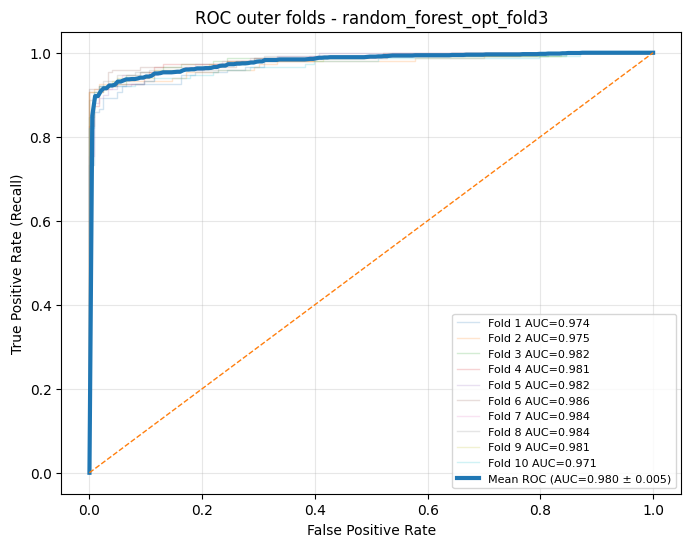

AUC CV mean for random_forest_opt_fold3: 0.9712,0.9801, best_threshold=0.2731
Evaluating model: extra_trees with pipeline 7
Evaluating model: extra_trees_opt_fold7
  Outer fold 01 | best_threshold=0.3770 | Acc CV=0.9309 | Acc Test=0.9048 | cv_f1=0.9386 | cv_fbeta_2.0=0.9513 | test_f1=0.9103 | test_fbeta_2.0=0.8919 | test_recall=0.8800 | test_precision=0.9429 | test_fn=18
  Outer fold 02 | best_threshold=0.2850 | Acc CV=0.8995 | Acc Test=0.8901 | cv_f1=0.9128 | cv_fbeta_2.0=0.9348 | test_f1=0.9038 | test_fbeta_2.0=0.9252 | test_recall=0.9400 | test_precision=0.8704 | test_fn=9
  Outer fold 03 | best_threshold=0.2940 | Acc CV=0.8963 | Acc Test=0.9231 | cv_f1=0.9109 | cv_fbeta_2.0=0.9340 | test_f1=0.9320 | test_fbeta_2.0=0.9486 | test_recall=0.9600 | test_precision=0.9057 | test_fn=6
  Outer fold 04 | best_threshold=0.2530 | Acc CV=0.8785 | Acc Test=0.8791 | cv_f1=0.8977 | cv_fbeta_2.0=0.9394 | test_f1=0.8985 | test_fbeta_2.0=0.9419 | test_recall=0.9733 | test_precision=0.8343 | test_fn=4

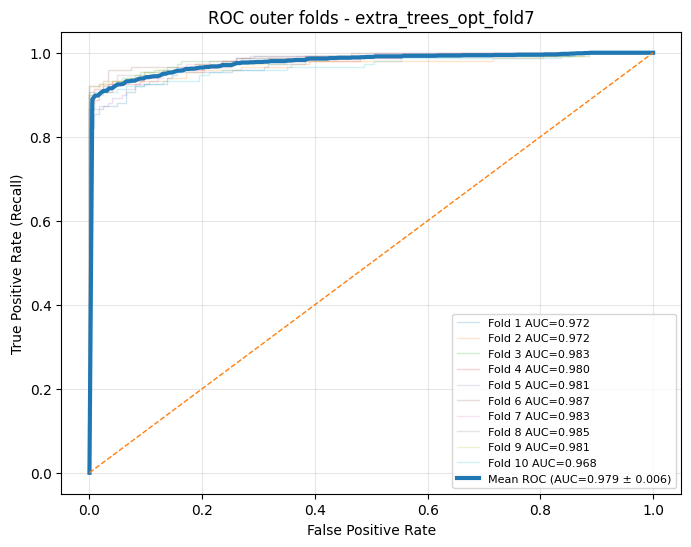

AUC CV mean for extra_trees_opt_fold7: 0.9705,0.9792, best_threshold=0.2971
Evaluating model: logistic_regression with pipeline 7
Evaluating model: logistic_regression_opt_fold7
  Outer fold 01 | best_threshold=0.1840 | Acc CV=0.8953 | Acc Test=0.8791 | cv_f1=0.9116 | cv_fbeta_2.0=0.9519 | test_f1=0.8939 | test_fbeta_2.0=0.9133 | test_recall=0.9267 | test_precision=0.8634 | test_fn=11
  Outer fold 02 | best_threshold=0.1570 | Acc CV=0.8733 | Acc Test=0.8755 | cv_f1=0.8961 | cv_fbeta_2.0=0.9401 | test_f1=0.8938 | test_fbeta_2.0=0.9286 | test_recall=0.9533 | test_precision=0.8412 | test_fn=7
  Outer fold 03 | best_threshold=0.2240 | Acc CV=0.8995 | Acc Test=0.8938 | cv_f1=0.9134 | cv_fbeta_2.0=0.9418 | test_f1=0.9068 | test_fbeta_2.0=0.9264 | test_recall=0.9400 | test_precision=0.8758 | test_fn=9
  Outer fold 04 | best_threshold=0.1650 | Acc CV=0.8618 | Acc Test=0.8352 | cv_f1=0.8864 | cv_fbeta_2.0=0.9352 | test_f1=0.8680 | test_fbeta_2.0=0.9355 | test_recall=0.9867 | test_precision=0.77

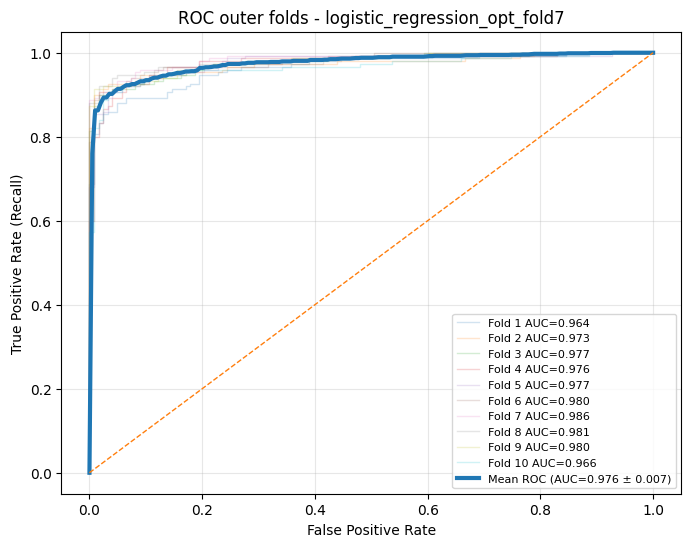

AUC CV mean for logistic_regression_opt_fold7: 0.9693,0.9759, best_threshold=0.1958
Evaluating model: xgboost with pipeline 10
Evaluating model: xgboost_opt_fold10
  Outer fold 01 | best_threshold=0.2530 | Acc CV=0.9162 | Acc Test=0.9048 | cv_f1=0.9272 | cv_fbeta_2.0=0.9476 | test_f1=0.9133 | test_fbeta_2.0=0.9133 | test_recall=0.9133 | test_precision=0.9133 | test_fn=13
  Outer fold 02 | best_threshold=0.1410 | Acc CV=0.8639 | Acc Test=0.8938 | cv_f1=0.8875 | cv_fbeta_2.0=0.9335 | test_f1=0.9085 | test_fbeta_2.0=0.9387 | test_recall=0.9600 | test_precision=0.8623 | test_fn=6
  Outer fold 03 | best_threshold=0.2140 | Acc CV=0.9099 | Acc Test=0.9048 | cv_f1=0.9210 | cv_fbeta_2.0=0.9361 | test_f1=0.9177 | test_fbeta_2.0=0.9465 | test_recall=0.9667 | test_precision=0.8735 | test_fn=5
  Outer fold 04 | best_threshold=0.1390 | Acc CV=0.8660 | Acc Test=0.8498 | cv_f1=0.8893 | cv_fbeta_2.0=0.9387 | test_f1=0.8783 | test_fbeta_2.0=0.9403 | test_recall=0.9867 | test_precision=0.7914 | test_fn=2

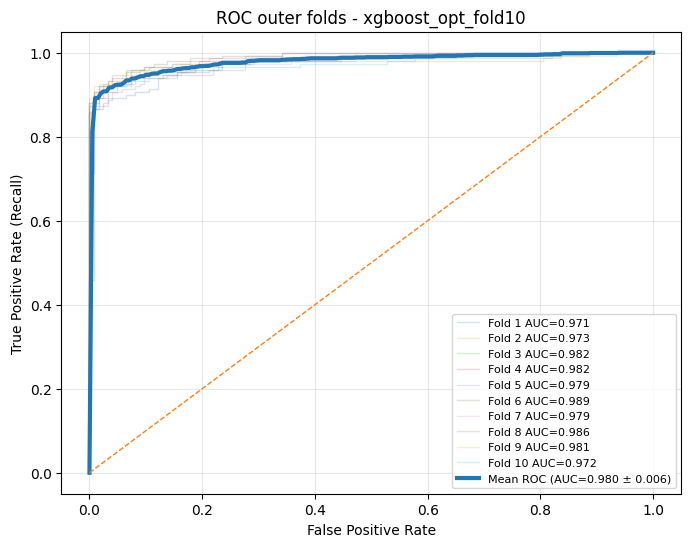

AUC CV mean for xgboost_opt_fold10: 0.9691,0.9795, best_threshold=0.1951
Evaluating model: adaboost with pipeline 1
Evaluating model: adaboost_opt_fold1
  Outer fold 01 | best_threshold=0.4450 | Acc CV=0.9194 | Acc Test=0.9158 | cv_f1=0.9296 | cv_fbeta_2.0=0.9463 | test_f1=0.9226 | test_fbeta_2.0=0.9170 | test_recall=0.9133 | test_precision=0.9320 | test_fn=13
  Outer fold 02 | best_threshold=0.3990 | Acc CV=0.8639 | Acc Test=0.8864 | cv_f1=0.8876 | cv_fbeta_2.0=0.9359 | test_f1=0.9022 | test_fbeta_2.0=0.9322 | test_recall=0.9533 | test_precision=0.8563 | test_fn=7
  Outer fold 03 | best_threshold=0.4060 | Acc CV=0.8639 | Acc Test=0.8755 | cv_f1=0.8895 | cv_fbeta_2.0=0.9349 | test_f1=0.8957 | test_fbeta_2.0=0.9407 | test_recall=0.9733 | test_precision=0.8295 | test_fn=4
  Outer fold 04 | best_threshold=0.4090 | Acc CV=0.8827 | Acc Test=0.8718 | cv_f1=0.9010 | cv_fbeta_2.0=0.9349 | test_f1=0.8930 | test_fbeta_2.0=0.9395 | test_recall=0.9733 | test_precision=0.8249 | test_fn=4
  Outer fo

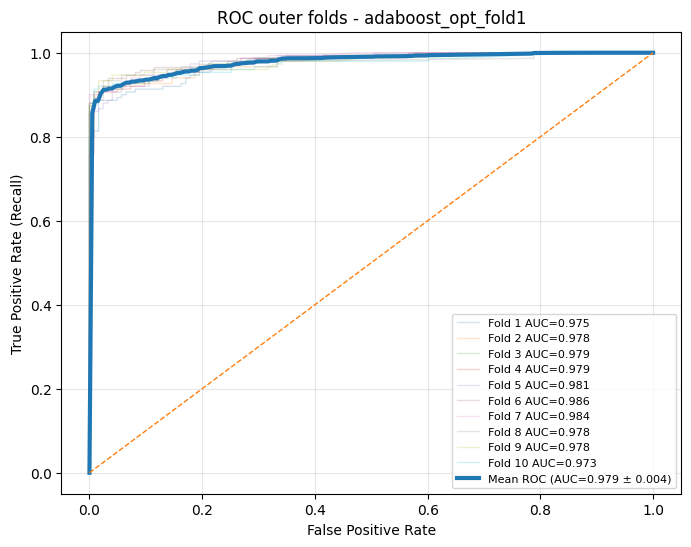

AUC CV mean for adaboost_opt_fold1: 0.9688,0.9792, best_threshold=0.4196
Evaluating model: svm with pipeline 8
Evaluating model: svm_opt_fold8
  Outer fold 01 | best_threshold=0.3030 | Acc CV=0.9298 | Acc Test=0.9194 | cv_f1=0.9375 | cv_fbeta_2.0=0.9497 | test_f1=0.9236 | test_fbeta_2.0=0.9011 | test_recall=0.8867 | test_precision=0.9638 | test_fn=17
  Outer fold 02 | best_threshold=0.2130 | Acc CV=0.9037 | Acc Test=0.9524 | cv_f1=0.9168 | cv_fbeta_2.0=0.9375 | test_f1=0.9565 | test_fbeta_2.0=0.9546 | test_recall=0.9533 | test_precision=0.9597 | test_fn=7
  Outer fold 03 | best_threshold=0.1920 | Acc CV=0.9183 | Acc Test=0.8974 | cv_f1=0.9281 | cv_fbeta_2.0=0.9436 | test_f1=0.9097 | test_fbeta_2.0=0.9276 | test_recall=0.9400 | test_precision=0.8812 | test_fn=9
  Outer fold 04 | best_threshold=0.1700 | Acc CV=0.8827 | Acc Test=0.8901 | cv_f1=0.9026 | cv_fbeta_2.0=0.9375 | test_f1=0.9068 | test_fbeta_2.0=0.9456 | test_recall=0.9733 | test_precision=0.8488 | test_fn=4
  Outer fold 05 | be

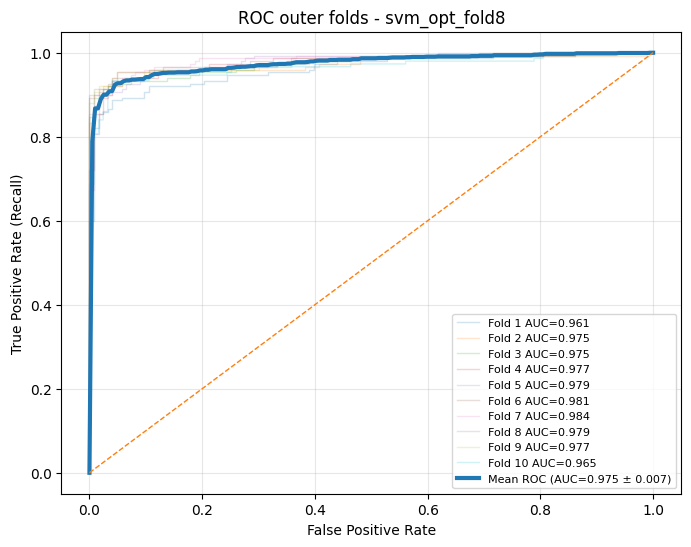

AUC CV mean for svm_opt_fold8: 0.9675,0.9753, best_threshold=0.2097
Evaluating model: knn with pipeline 2
Evaluating model: knn_opt_fold2
  Outer fold 01 | best_threshold=0.0940 | Acc CV=0.9047 | Acc Test=0.8901 | cv_f1=0.9171 | cv_fbeta_2.0=0.9411 | test_f1=0.9020 | test_fbeta_2.0=0.9127 | test_recall=0.9200 | test_precision=0.8846 | test_fn=12
  Outer fold 02 | best_threshold=0.0710 | Acc CV=0.8712 | Acc Test=0.8388 | cv_f1=0.8930 | cv_fbeta_2.0=0.9244 | test_f1=0.8667 | test_fbeta_2.0=0.9167 | test_recall=0.9533 | test_precision=0.7944 | test_fn=7
  Outer fold 03 | best_threshold=0.1250 | Acc CV=0.8555 | Acc Test=0.9194 | cv_f1=0.8854 | cv_fbeta_2.0=0.9302 | test_f1=0.9276 | test_fbeta_2.0=0.9350 | test_recall=0.9400 | test_precision=0.9156 | test_fn=9
  Outer fold 04 | best_threshold=0.0650 | Acc CV=0.8387 | Acc Test=0.7546 | cv_f1=0.8685 | cv_fbeta_2.0=0.9174 | test_f1=0.8144 | test_fbeta_2.0=0.9063 | test_recall=0.9800 | test_precision=0.6967 | test_fn=3
  Outer fold 05 | best_th

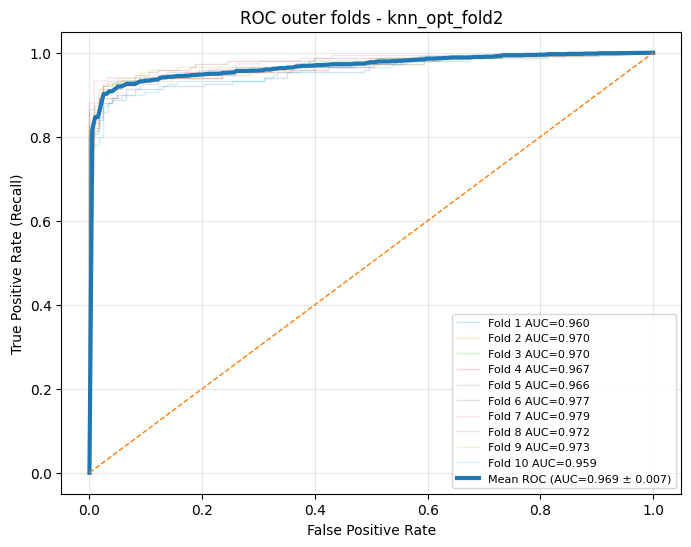

AUC CV mean for knn_opt_fold2: 0.9603,0.9693, best_threshold=0.1087
Evaluating model: gaussian_nb with pipeline 9
Evaluating model: gaussian_nb_opt_fold9
  Outer fold 01 | best_threshold=1.0000 | Acc CV=0.9277 | Acc Test=0.9048 | cv_f1=0.9340 | cv_fbeta_2.0=0.9324 | test_f1=0.9085 | test_fbeta_2.0=0.8787 | test_recall=0.8600 | test_precision=0.9627 | test_fn=21
  Outer fold 02 | best_threshold=1.0000 | Acc CV=0.9183 | Acc Test=0.9414 | cv_f1=0.9244 | cv_fbeta_2.0=0.9148 | test_f1=0.9448 | test_fbeta_2.0=0.9257 | test_recall=0.9133 | test_precision=0.9786 | test_fn=13
  Outer fold 03 | best_threshold=1.0000 | Acc CV=0.9131 | Acc Test=0.9304 | cv_f1=0.9201 | cv_fbeta_2.0=0.9131 | test_f1=0.9347 | test_fbeta_2.0=0.9177 | test_recall=0.9067 | test_precision=0.9645 | test_fn=14
  Outer fold 04 | best_threshold=1.0000 | Acc CV=0.9141 | Acc Test=0.9121 | cv_f1=0.9198 | cv_fbeta_2.0=0.9047 | test_f1=0.9195 | test_fbeta_2.0=0.9158 | test_recall=0.9133 | test_precision=0.9257 | test_fn=13
  Oute

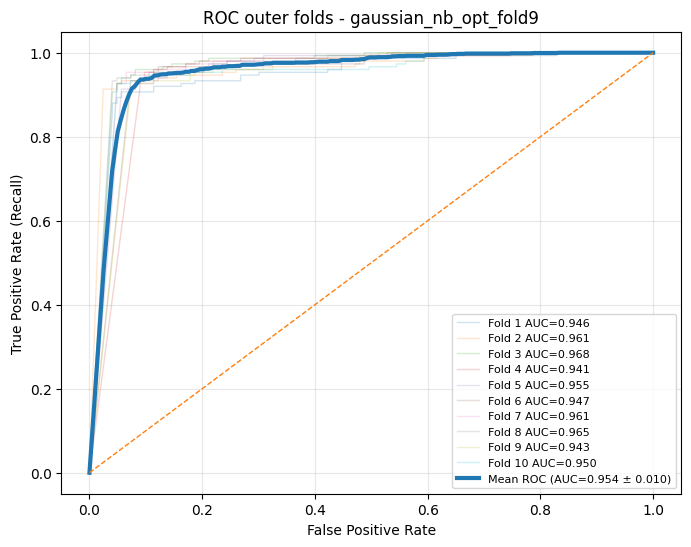

AUC CV mean for gaussian_nb_opt_fold9: 0.9415,0.9538, best_threshold=0.9998
Evaluating model: decision_tree with pipeline 10
Evaluating model: decision_tree_opt_fold10
  Outer fold 01 | best_threshold=0.4470 | Acc CV=0.8953 | Acc Test=0.8901 | cv_f1=0.9099 | cv_fbeta_2.0=0.9276 | test_f1=0.8973 | test_fbeta_2.0=0.8827 | test_recall=0.8733 | test_precision=0.9225 | test_fn=19
  Outer fold 02 | best_threshold=0.1950 | Acc CV=0.8628 | Acc Test=0.8681 | cv_f1=0.8847 | cv_fbeta_2.0=0.9251 | test_f1=0.8882 | test_fbeta_2.0=0.9262 | test_recall=0.9533 | test_precision=0.8314 | test_fn=7
  Outer fold 03 | best_threshold=0.1390 | Acc CV=0.8283 | Acc Test=0.8608 | cv_f1=0.8620 | cv_fbeta_2.0=0.9186 | test_f1=0.8855 | test_fbeta_2.0=0.9399 | test_recall=0.9800 | test_precision=0.8077 | test_fn=3
  Outer fold 04 | best_threshold=0.1470 | Acc CV=0.8188 | Acc Test=0.8462 | cv_f1=0.8551 | cv_fbeta_2.0=0.9145 | test_f1=0.8735 | test_fbeta_2.0=0.9271 | test_recall=0.9667 | test_precision=0.7967 | test_

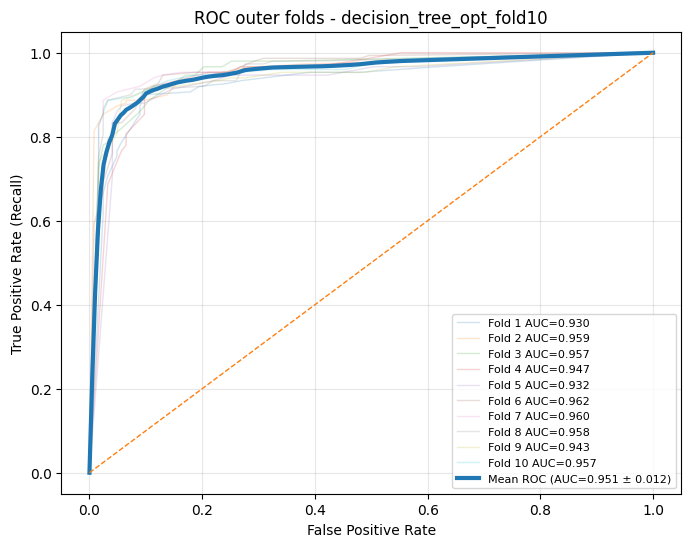

AUC CV mean for decision_tree_opt_fold10: 0.9371,0.9506, best_threshold=0.2300


In [ ]:
list_results = []
for model in dicts_models:
    model_name = model.split("_opt_fold")[0]
    model_fold = model.split("_opt_fold")[1]

    if X_full_domain[model_name] == 'X_STATS':
        X_path = X_multiples['X_STATS']
        X_cols = cols_updrs_full['X_STATS']
    elif X_full_domain[model_name] == 'X_V06_STATS':
        X_path = X_multiples['X_V06_STATS']
        X_cols = cols_updrs_full['X_V06_STATS']
    elif X_full_domain[model_name] == 'X_V06_DELTA':
        X_path = X_multiples['X_V06_DELTA']
        X_cols = cols_updrs_full['X_V06_DELTA']
    
    X = pd.read_csv(X_path, index_col=0)[X_cols]
    y = pd.read_csv(y_multiples['HY2'], index_col=0).squeeze()
    print(f'Evaluating model: {model_name} with pipeline {model_fold}')
    df_metrics = evaluate_model_10x10_metrics_binary_auc_plot(
        model_dict={model: dicts_models[model]},
        X=X,
        y=y,
        n_outer=10, 
        n_inner=5,  
    )
    print(f'AUC CV mean for {model}: {df_metrics["auc_cv_mean"].values[0]:.4f},{df_metrics["auc_test_mean"].values[0]:.4f}, best_threshold={df_metrics["best_threshold_mean"].values[0]:.4f}')
    list_results.append(df_metrics)
df_full_Bayes_AUC_tresh = pd.concat(list_results, ignore_index=True)
df_full_Bayes_AUC_tresh.to_csv(f'{project_root}/SCRIPTS/PYTHON/MODEL_ANALYSIS/Performance_Results/HY2/UPDRS/BAYES_AUC_THRESHOLD_HY2.csv', index=False)

In [ ]:
df_full_Bayes_AUC_tresh

,model,target_type,classes,n_classes,accuracy_cv_mean,accuracy_cv_std,accuracy_test_mean,accuracy_test_std,f1_cv_mean,f1_cv_std,...,fpr_cv_mean,fpr_cv_std,fpr_test_mean,fpr_test_std,fnr_cv_mean,fnr_cv_std,fnr_test_mean,fnr_test_std,best_threshold_mean,best_threshold_std
0,random_forest_opt_fold3,binary,"[0, 1]",2,0.891099,0.015903,0.890110,0.041693,0.907824,0.012196,...,0.191860,0.040344,0.189431,0.121623,0.040952,0.009513,0.044667,0.029489,0.2731,0.080477
1,extra_trees_opt_fold7,binary,"[0, 1]",2,0.893089,0.021405,0.899634,0.027585,0.909197,0.016084,...,0.187907,0.053255,0.163415,0.088602,0.040571,0.008615,0.048667,0.032667,0.2971,0.058213
2,logistic_regression_opt_fold7,binary,"[0, 1]",2,0.883141,0.019672,0.883150,0.032140,0.902198,0.014029,...,0.219535,0.049018,0.209756,0.086364,0.032762,0.007661,0.040667,0.020233,0.1958,0.032615
3,xgboost_opt_fold10,binary,"[0, 1]",2,0.886702,0.017994,0.891941,0.023375,0.904283,0.013465,...,0.206047,0.045535,0.196748,0.066911,0.037333,0.007940,0.035333,0.020620,0.1951,0.041635
4,adaboost_opt_fold1,binary,"[0, 1]",2,0.882827,0.023370,0.887546,0.025962,0.901632,0.016841,...,0.210000,0.061373,0.200000,0.081499,0.041143,0.009844,0.040667,0.022760,0.4196,0.020408
5,svm_opt_fold8,binary,"[0, 1]",2,0.896963,0.025335,0.904396,0.034555,0.912373,0.018715,...,0.178372,0.061569,0.147154,0.098120,0.041333,0.006352,0.053333,0.026294,0.2097,0.056594
6,knn_opt_fold2,binary,"[0, 1]",2,0.876649,0.030912,0.882418,0.054453,0.896708,0.021364,...,0.210698,0.078492,0.196748,0.136085,0.051810,0.012403,0.052667,0.017902,0.1087,0.030492
7,gaussian_nb_opt_fold9,binary,"[0, 1]",2,0.919372,0.004911,0.927839,0.012695,0.925297,0.004660,...,0.067442,0.009431,0.053659,0.019617,0.091429,0.009331,0.087333,0.020716,0.9998,0.000422
8,decision_tree_opt_fold10,binary,"[0, 1]",2,0.849738,0.026107,0.863370,0.027739,0.875422,0.018504,...,0.269302,0.067293,0.235772,0.080026,0.052762,0.010851,0.055333,0.028293,0.2300,0.095120


## SHAP

In [ ]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import StratifiedShuffleSplit


def shap_cv(
    model,
    X,
    y,
    n_splits=10,
    test_size=0.30,
    random_state=42,
    positive_class=1,
    background_size=200,
    max_display=20
):
    """
    Versión simple de SHAP con validación cruzada externa.

    Qué hace:
    - divide los datos varias veces en train/test
    - entrena el modelo en cada fold
    - calcula SHAP en el conjunto de test
    - opcionalmente dibuja un beeswarm por fold
    - resume la importancia media absoluta por variable
    - agrega resultados al final

    Requisitos:
    - X debe ser pandas DataFrame
    - y debe ser binario {0,1}
    - model debe ser un pipeline sklearn
    - el último paso del pipeline debe llamarse 'model'
    """

    # -----------------------------
    # 1. Validaciones básicas
    # -----------------------------
    if not isinstance(X, pd.DataFrame):
        raise ValueError("X debe ser un DataFrame.")

    y = pd.Series(y).reset_index(drop=True)
    X = X.reset_index(drop=True).copy()

    feature_names = list(X.columns)

    # Aquí guardaremos una fila por feature y por fold
    all_shap_rows = []

    # Esto sirve para repetir splits manteniendo proporción de clases
    splitter = StratifiedShuffleSplit(
        n_splits=n_splits,
        test_size=test_size,
        random_state=random_state
    )

    # -----------------------------
    # 2. Loop de folds
    # -----------------------------
    for fold, (train_idx, test_idx) in enumerate(splitter.split(X, y), start=1):
        print(f"Procesando fold {fold}/{n_splits}...")

        X_train = X.iloc[train_idx].copy()
        X_test = X.iloc[test_idx].copy()
        y_train = y.iloc[train_idx].copy()

        # Clonamos el modelo para no reutilizar el mismo objeto
        est = clone(model)
        est.fit(X_train, y_train)

        # -----------------------------
        # 3. Transformar datos antes del modelo final
        # -----------------------------
        X_train_t = X_train
        X_test_t = X_test

        for step_name, step in est.named_steps.items():
            if step_name == "model":
                break
            X_train_t = step.transform(X_train_t)
            X_test_t = step.transform(X_test_t)

        # Sacamos el modelo final
        model_final = est.named_steps["model"]

        # -----------------------------
        # 4. Crear nombres de variables
        # -----------------------------
        if isinstance(X_test_t, pd.DataFrame):
            selected_features = list(X_test_t.columns)
            X_test_plot = X_test_t.copy()
        else:
            n_cols = X_test_t.shape[1]
            if n_cols == len(feature_names):
                selected_features = feature_names
            else:
                selected_features = [f"feature_{i}" for i in range(n_cols)]

            X_test_plot = pd.DataFrame(X_test_t, columns=selected_features)

        # -----------------------------
        # 5. Elegir background para SHAP
        # -----------------------------
        n_bg = min(background_size, len(X_train_t))
        rng = np.random.RandomState(random_state + fold)
        bg_idx = rng.choice(len(X_train_t), size=n_bg, replace=False)

        if isinstance(X_train_t, pd.DataFrame):
            background = X_train_t.iloc[bg_idx].copy()
        else:
            background = X_train_t[bg_idx]

        # -----------------------------
        # 6. Función que SHAP va a explicar
        # -----------------------------
        def predict_proba_positive(data):
            return model_final.predict_proba(data)[:, positive_class]

        # Creamos explainer genérico
        explainer = shap.Explainer(predict_proba_positive, background)

        # Calculamos SHAP sobre test
        n_features = X_test_t.shape[1]
        max_evals = max(1000, 2 * n_features + 1)

        shap_exp = explainer(X_test_t, max_evals=max_evals)

        # -----------------------------
        # 6b. Beeswarm por fold 
        # -----------------------------
        
        plt.figure(figsize=(10, 6))
        shap.summary_plot(
                shap_exp.values,
                X_test_plot,
                max_display=max_display,
                show=False
            )
        plt.title(f"SHAP beeswarm - Fold {fold}")
        plt.tight_layout()
        plt.show()

        # -----------------------------
        # 7. Resumen por fold
        # -----------------------------
        mean_abs_shap = np.abs(shap_exp.values).mean(axis=0)

        for feat, val in zip(selected_features, mean_abs_shap):
            all_shap_rows.append({
                "fold": fold,
                "feature": feat,
                "mean_abs_shap": float(val)
            })

    # -----------------------------
    # 8. Convertir a DataFrame
    # -----------------------------
    shap_raw = pd.DataFrame(all_shap_rows)

    # Resumen global por feature
    shap_summary = (
        shap_raw
        .groupby("feature", as_index=False)
        .agg(
            mean_abs_shap=("mean_abs_shap", "mean"),
            std_abs_shap=("mean_abs_shap", "std"),
            median_abs_shap=("mean_abs_shap", "median"),
            n_folds=("fold", "count")
        )
        .sort_values("mean_abs_shap", ascending=False)
        .reset_index(drop=True)
    )

    shap_summary["std_abs_shap"] = shap_summary["std_abs_shap"].fillna(0.0)

    return {
        "shap_raw": shap_raw,
        "shap_summary": shap_summary
    }

In [ ]:
model_name = 'random_forest'
X = pd.read_csv(X_multiples[X_full_domain[model_name]], index_col=0)[cols_updrs_full[X_full_domain[model_name]]]
y = pd.read_csv(y_multiples['HY2'], index_col=0).squeeze()
print(f"Calculando SHAP para modelo: {model_name} con X shape: {X.shape}")
results = shap_cv(
    model=dicts_models['random_forest_opt_fold6'],
    X=X,
    y=y)

Calculando SHAP para modelo: random_forest con X shape: (909, 301)


KeyError: 'random_forest_opt_fold6'

# FINAL TEST

In [ ]:
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    roc_auc_score
)

# =========================
# Configuración
# =========================
model_name = 'random_forest'
threshold = 0.30

# =========================
# Pipeline
# =========================
pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(
        bootstrap=True,
        criterion='log_loss',
        max_depth=5,
        max_features='sqrt',
        min_samples_leaf=15,
        min_samples_split=23,
        n_estimators=429,
        random_state=42,
        n_jobs=-1
    ))
])

# =========================
# Carga de datos
# =========================
X_train = pd.read_csv(
    X_multiples[X_full_domain[model_name]],
    index_col=0
)[cols_updrs_full[X_full_domain[model_name]]]

X_test = pd.read_csv(
    '/home/fsc/Desktop/PD_progression_ppmi/SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_STATS_TEST.csv',
    index_col=0
)[cols_updrs_full[X_full_domain[model_name]]]

y_train = pd.read_csv(
    y_multiples['HY2'],
    index_col=0
).squeeze()

y_test = pd.read_csv(
    '/home/fsc/Desktop/PD_progression_ppmi/SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY2_TEST.csv',
    index_col=0
).squeeze()

# =========================
# Entrenamiento
# =========================
pipeline.fit(X_train, y_train)

# =========================
# TRAIN
# =========================
y_proba_train = pipeline.predict_proba(X_train)[:, 1]
y_pred_train = (y_proba_train >= threshold).astype(int)

acc_train = accuracy_score(y_train, y_pred_train)
f1_train = f1_score(y_train, y_pred_train)
recall_train = recall_score(y_train, y_pred_train)
precision_train = precision_score(y_train, y_pred_train)
auc_train = roc_auc_score(y_train, y_proba_train)

# =========================
# TEST
# =========================
y_proba_test = pipeline.predict_proba(X_test)[:, 1]
y_pred_test = (y_proba_test >= threshold).astype(int)

acc_test = accuracy_score(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test)
recall_test = recall_score(y_test, y_pred_test)
precision_test = precision_score(y_test, y_pred_test)
auc_test = roc_auc_score(y_test, y_proba_test)

# =========================
# Resultados
# =========================
print(f"Threshold : {threshold}")

print("\n=== TRAIN ===")
print("Accuracy  :", acc_train)
print("F1        :", f1_train)
print("Recall    :", recall_train)
print("Precision :", precision_train)
print("AUC       :", auc_train)

print("\n=== TEST ===")
print("Accuracy  :", acc_test)
print("F1        :", f1_test)
print("Recall    :", recall_test)
print("Precision :", precision_test)
print("AUC       :", auc_test)

Threshold : 0.3

=== TRAIN ===
Accuracy  : 0.9097909790979097
F1        : 0.9211538461538461
Recall    : 0.9560878243512974
Precision : 0.8886827458256029
AUC       : 0.982050604673007

=== TEST ===
Accuracy  : 0.9251968503937008
F1        : 0.9364548494983278
Recall    : 0.9722222222222222
Precision : 0.9032258064516129
AUC       : 0.9837594696969697
